# Проект: Обучение с учителем: качество модели

# Описание проекта

Интернет-магазин **«В один клик»** продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений.<br>

**«В один клик»** — современная компания, поэтому её руководство не хочет принимать решения просто так — только на основе анализа данных и бизнес-моделирования. У компании есть небольшой отдел цифровых технологий, и вам предстоит побыть в роли стажёра в этом отделе.<br> 

Итак, вашему отделу поручили разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.<br>

1. Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.
2. В исследование нужно включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца.
3. Используя данные модели и данные о прибыльности клиентов, нужно выделить сегменты покупателей и разработать для них персонализированные предложения.<br>

Руководство одобрило описание решения, и вам, как специалисту по DS, нужно его реализовать.

# Описание данных

1. Файл **`'market_file.csv'`** таблица, которая содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.

* **`'id'`** — номер покупателя в корпоративной базе данных.
* **`'Покупательская активность'`** — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
* **`'Тип сервиса'`** — уровень сервиса, например «премиум» и «стандарт».
* **`'Разрешить сообщать'`** — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
* **`'Маркет_актив_6_мес'`** — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
* **`'Маркет_актив_тек_мес'`** — количество маркетинговых коммуникаций в текущем месяце.
* **`'Длительность'`** — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
* **`'Акционные_покупки'`** — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
* **`'Популярная_категория'`** — самая популярная категория товаров у покупателя за последние 6 месяцев.
* **`'Средний_просмотр_категорий_за_визит'`** — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
* **`'Неоплаченные_продукты_штук_квартал'`** — общее число неоплаченных товаров в корзине за последние 3 месяца.
* **`'Ошибка_сервиса'`** — число сбоев, которые коснулись покупателя во время посещения сайта.
* **`'Страниц_за_визит'`** — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.

2. Файл **`'market_money.csv'`** таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.

* **`'id'`** — номер покупателя в корпоративной базе данных.
* **`'Период'`** — название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц'.
* **`'Выручка'`** — сумма выручки за период.

3. Файл **`'market_time.csv'`** таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.

* **`'id'`** — номер покупателя в корпоративной базе данных.
* **`'Период'`** — название периода, во время которого зафиксировано общее время.
* **`'минут'`** — значение времени, проведённого на сайте, в минутах.

4. Файл **`'money.csv'`** Таблица с данными о среднемесячной прибыли продавца за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.

* **`'id'`** — номер покупателя в корпоративной базе данных.
* **`'Прибыль'`** — значение прибыли.

# План исследования

* Загрузка и изучение данных
* Предобработка данных
* Исследовательский анализ данных
* Объединение таблиц
* Корреляционный анализ
* Использование пайплайнов
* Анализ важности признаков
* Сегментация покупателей
* Общий вывод

## Загрузка данных

In [1]:
#!pip install scikit-learn==1.1.3 -q
#!pip install matplotlib==3.5.2 -q

In [2]:
!pip install phik -q
!pip install shap -q

In [3]:
import pandas as pd
import os
import re
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

import phik
import shap

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, \
     StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.metrics import roc_auc_score

from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [4]:
#df_market_file = pd.read_csv('/home/datasets/data_learning_teacher/market_file.csv')
#df_market_money = pd.read_csv('/datasets/data_learning_teacher/market_money.csv')
#df_market_time = pd.read_csv('/datasets/data_learning_teacher/market_time.csv')
#df_money_mean = pd.read_csv('/datasets/data_learning_teacher/money.csv', sep=';', skipinitialspace=True)

base_path = r'C:\Users\admin\datasets\data_learning_teacher'

df_market_file = pd.read_csv(os.path.join(base_path, 'market_file.csv'))
df_market_money = pd.read_csv(os.path.join(base_path, 'market_money.csv'))
df_market_time = pd.read_csv(os.path.join(base_path, 'market_time.csv'))

# Загружаем money.csv с указанными параметрами
df_money_mean = pd.read_csv(
    os.path.join(base_path, 'money.csv'), 
    sep=';', 
    skipinitialspace=True
)

In [5]:
df_market_file.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [6]:
df_market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [7]:
df_market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [8]:
df_market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [9]:
df_market_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [10]:
df_market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [11]:
df_money_mean.head()

,id,Прибыль
0,215348,"0,98"
1,215349,"4,16"
2,215350,"3,13"
3,215351,"4,87"
4,215352,"4,21"


In [12]:
df_money_mean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       1300 non-null   int64 
 1   Прибыль  1300 non-null   object
dtypes: int64(1), object(1)
memory usage: 20.4+ KB


Данные загрузились без проблем и ошибок. Есть недочет, который мы устраним на данном этапе:
* приведем название колонок согласно принятым договоренностям стандарта PEP-8;

In [13]:
dfs = [
    df_market_file,
    df_market_money,
    df_market_time,
    df_money_mean
]

for df in dfs:
    df.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', i).replace(' ','_').lower() for i in df.columns]

In [14]:
df_market_file.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


### Промежуточный вывод

При загрузке данных (4 датасета) был применен разделитель ';' в одном из них ддля лучшего  отображения. 
В целом по данным наблюдается ровное количество строк, что может говорить об отсутствии пропусков. Необходимо будет изменить тип данных в датасете **`'df_money_mean`'** в колонке **прибыль** с типа **`'object на float64`'**.<br>
Нименование столбцов переименованы согласно принятым правилам. В целом данные соответствуют описанию.<br> Всего у нас получилось 4 датасета:
* **`'df_market_file`'**
    * содержит 12 стобцов и 1300 строк
* **`'df_market_money`'**
    * содержит 3 стобца и 3900 строк
* **`'df_market_time`'**
    * содержит 2 стобца и 2600 строк
* **`'df_money_mean`'**
    * содержит 2 стобца и 1300 строк

## Предобработка данных

### Проверим на наличие явных дубликатов все 4 датасета, при наличии удалим их.

In [15]:
df_market_file.duplicated().sum()

0

In [16]:
df_market_money.duplicated().sum()

0

In [17]:
df_market_time.duplicated().sum()

0

In [18]:
df_money_mean.duplicated().sum()

0

### Проверим наличие неявных дубликатов в наших данных

In [19]:
def checking_duplicates(a):
    for column in a.select_dtypes(exclude=['number']).columns:
        print(f"Уникальные значения в '{column}': {a[column].unique()}")

In [20]:
checking_duplicates(df_market_file)

Уникальные значения в 'покупательская_активность': ['Снизилась' 'Прежний уровень']
Уникальные значения в 'тип_сервиса': ['премиум' 'стандартт' 'стандарт']
Уникальные значения в 'разрешить_сообщать': ['да' 'нет']
Уникальные значения в 'популярная_категория': ['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']


In [21]:
checking_duplicates(df_market_money)

Уникальные значения в 'период': ['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']


In [22]:
checking_duplicates(df_market_time)

Уникальные значения в 'период': ['текущий_месяц' 'предыдцщий_месяц']


Исправим ошибку в колонке **'период'** в датасете **`'df_market_time'`**:
* `'предыдущий_месяц'` вместо `'предыдцщий_месяц'`

In [23]:
df_market_time['период'].replace('предыдцщий_месяц', 'предыдущий_месяц', inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_16564\3082074705.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_market_time['период'].replace('предыдцщий_месяц', 'предыдущий_месяц', inplace=True)


Приведем данные в датасете **`'df_market_file'`** к одному виду:
* `'стандарт'` вместо `'стандартт'`

In [24]:
df_market_file['тип_сервиса'].replace('стандартт', 'стандарт', inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_16564\87995635.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_market_file['тип_сервиса'].replace('стандартт', 'стандарт', inplace=True)


In [25]:
df_market_file['тип_сервиса'].unique()

array(['премиум', 'стандарт'], dtype=object)

### Изменим тип данных в датасете **`'df_money_mean`'** в колонке 'прибыль' с типа **`'object на float64`'**

In [26]:
df_money_mean['прибыль'] = (
    df_money_mean['прибыль']
    .replace(',', '.', regex=True)
    .astype(float)
)
df_money_mean['прибыль'].dtype

dtype('float64')

### Проверим наши числовые значения в датасетах.

In [27]:
df_market_file.describe()

,id,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,215997.500000,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,375.421985,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,215348.000000,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,215672.750000,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,215997.500000,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,216322.250000,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,216647.000000,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


In [28]:
df_market_money.describe()

,id,выручка
count,3900.000000,3900.000000
mean,215997.500000,5025.696051
std,375.325686,1777.704104
min,215348.000000,0.000000
25%,215672.750000,4590.150000
50%,215997.500000,4957.500000
75%,216322.250000,5363.000000
max,216647.000000,106862.200000


In [29]:
df_market_money[df_market_money['выручка'] > 8000]

,id,период,выручка
98,215380,текущий_месяц,106862.2


In [30]:
df_market_file[df_market_file['id'] == 215380]

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
32,215380,Снизилась,премиум,нет,1.7,4,637,0.94,Техника для красоты и здоровья,3,2,4,7


Это слишком значительны выброс, чтобы его оставить. Удалим данную строку.

In [31]:
df_market_money = df_market_money[df_market_money['выручка'] < 8000]

In [32]:
df_market_money[df_market_money['выручка'] > 8000]

,id,период,выручка


In [33]:
df_market_time.describe()

,id,минут
count,2600.000000,2600.000000
mean,215997.500000,13.336154
std,375.349754,4.080198
min,215348.000000,4.000000
25%,215672.750000,10.000000
50%,215997.500000,13.000000
75%,216322.250000,16.000000
max,216647.000000,23.000000


In [34]:
df_money_mean.describe()

,id,прибыль
count,1300.000000,1300.000000
mean,215997.500000,3.996631
std,375.421985,1.013722
min,215348.000000,0.860000
25%,215672.750000,3.300000
50%,215997.500000,4.045000
75%,216322.250000,4.670000
max,216647.000000,7.430000


По числовым значениям все нормально, артефактов не обнаружено.

### Промежуточный вывод

На данном этапе мы проверили:
* проверили на наличие дубликатов:
    * явные дубликаты не обнаружены;
    * обнаружили неявные дубликаты в датасете **`'df_market_file'`**, привели данные к одному виду
* привели в соответствие данным их тип в датасете **`'df_money_mean`'**;
* приоверили на содержание артефактов числовые значения во всех датафреймах - отстутствуют.

## Исследовательский анализ данных

* Проведем исследовательский анализ данных из каждой таблицы. 
* Отберем клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в этот период.

### Посмотрим на распределения признаков. 

Для этого напишем функции, которые будут строить графики распределения.
Первая функция будет строить графики ('Гистрограмма' и 'Ящик с усами') для числовых непрерывных значений.

In [35]:
def plotting_graphs_hist(a, b, c, d, e, xlim=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    fig.suptitle(b, fontsize=14, y=1.02)
    
    a.plot(kind='hist', bins=e, color='#AC1080', grid=True, ax=ax1)
    ax1.set_title(" (Гистограмма)", size=12)
    ax1.set_xlabel(c, size=12)
    ax1.set_ylabel(d, size=12)
    if xlim:
        ax1.set_xlim(xlim[0], xlim[1])
    
    a.name = None
    a.plot(kind='box', vert=False, patch_artist=True, 
           boxprops=dict(facecolor='#1E90FF'), ax=ax2)
    ax2.set_title(" (Ящик с усами)", size=12)
    ax2.set_xlabel(c, size=12)
    ax2.set_ylabel('') 
    ax2.set_yticklabels([])
    
    plt.tight_layout()
    plt.show()
    print(a.describe())

Следующие функции напишем для дискретных или категорийных значений.

In [36]:
def plotting_graphs_bar_num(a, b, c, d):
    (a.value_counts().sort_index()
    .plot(kind='bar', grid=True, width=0.8, figsize=(14,6))
    )
    
    plt.xticks(rotation=0)
    plt.title(b, size=15)
    plt.xlabel(c, size=14)
    plt.ylabel(d, size=14)
    plt.show()
    plotting_graphs_box(a, b, c)

In [37]:
def plotting_graphs_box(a, b, c):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), 
                                  gridspec_kw={'width_ratios': [1, 1]}) 
    
    a.name = ''
    a.plot(kind='box', vert=False, patch_artist=True, 
           boxprops=dict(facecolor='#1E90FF'), ax=ax1)
    ax1.set_title(b, size=12)
    ax1.set_xlabel(c, size=12)
    ax1.set_ylabel('') 
    
    ax2.axis('off')
    describe_data = a.describe().to_string(float_format="%.2f")
    ax2.text(0.35, 0.5, describe_data, fontfamily='monospace', va='center', ha='left', fontsize=15)
    ax2.set_title("Описательная статистика", size=12)
    
    plt.tight_layout()
    plt.show()

In [38]:
def plotting_graphs_bar_cat(a, b, c, d):
    (a.value_counts().sort_index()
    .plot(kind='bar', grid=True, width=0.8, figsize=(14,6))
    )
    
    plt.xticks(rotation=30)
    plt.title(b, size=15)
    plt.xlabel(c, size=14)
    plt.ylabel(d, size=14)
    plt.show()

Пятая функция у нас будет строить диаграммы для бинарных признаков.

In [39]:
def plotting_graphs_pie(a, b):
    counts = a.value_counts(normalize=True)
    n = len(counts)
    
    (counts.plot(kind='pie', autopct='%.1f%%', startangle=45,
               colors=['#4CAF50', '#FF5722', '#2196F3'][:n],
               shadow=True, 
               explode=tuple([0.05] + [0]*(n-1)),
               figsize=(6, 6),
               textprops={'fontsize': 14})
    )
    plt.title(b, size=12)
    plt.ylabel('')
    plt.show()

### Приступим к построению графиков распределения. 

#### Начнем по порядку с датасета **`'df_market_file'`**:
* **`'покупательская_активность'`**

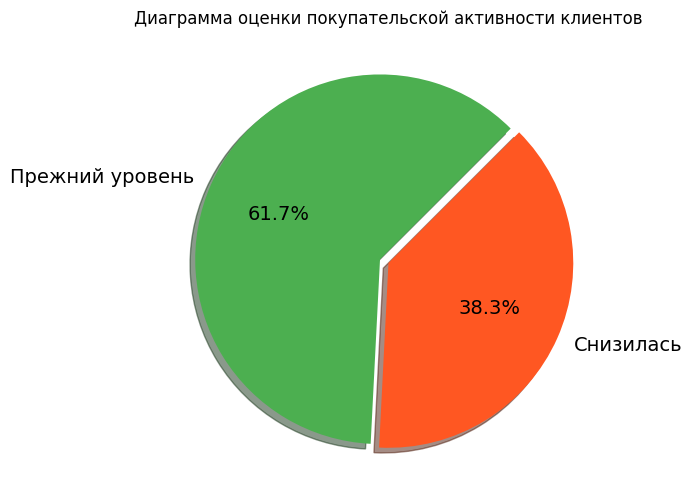

In [40]:
b = 'Диаграмма оценки покупательской активности клиентов'
plotting_graphs_pie(df_market_file['покупательская_активность'], b)

Бинарный признак активности покупателей. По данной диаграмме мы видим преобладание прежнего уровня активности над текущей, в соотношении 61.7/38.3, что считается умеренным дисбалансом. В данной ситуации так как это признак является целевым для нас в дальнейшем, то от этого зависит выбор метрик для анализа нашей модели. В данном случае при дисбалансе **`'accuracy'`** становится ненадёжной. Более надежным будет метрика **`'Precision'`**, нам важно минимизировать ложные срабатывания **(FP)**.

* **`'тип_сервиса'`**

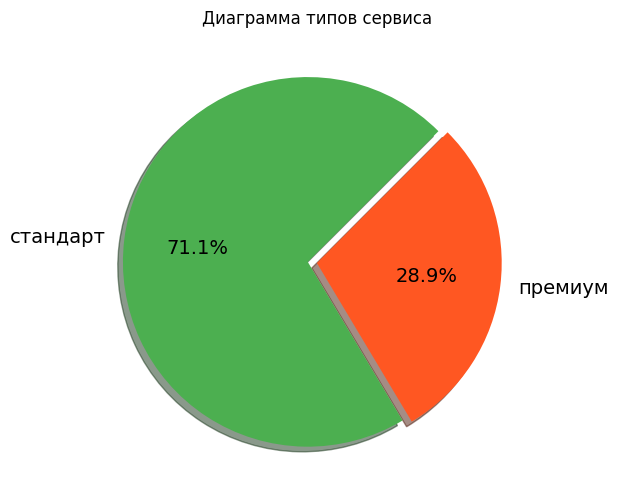

In [41]:
b = 'Диаграмма типов сервиса'
plotting_graphs_pie(df_market_file['тип_сервиса'], b)

Бинарный признак типа сервиса. По данной диаграмме мы видим преобладание стандартного сервиса над премиум, в соотношении 71.1/28.9, что считается сильным дисбалансом.

* **`'разрешить_сообщать'`**

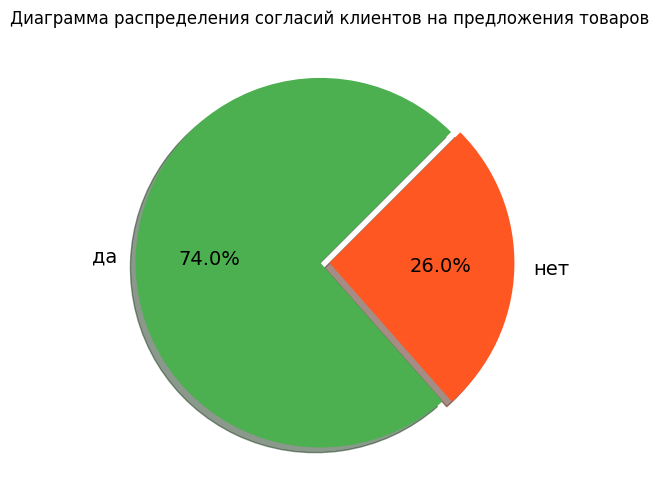

In [42]:
b = 'Диаграмма распределения согласий клиентов на предложения товаров'
plotting_graphs_pie(df_market_file['разрешить_сообщать'], b)

Бинарный признак типа сервиса. По данной диаграмме мы видим преобладание разрешения клиентов на рекламу над запретом, в соотношении 74/26, что считается сильным дисбалансом.

* **`'маркет_актив_6_мес'`**

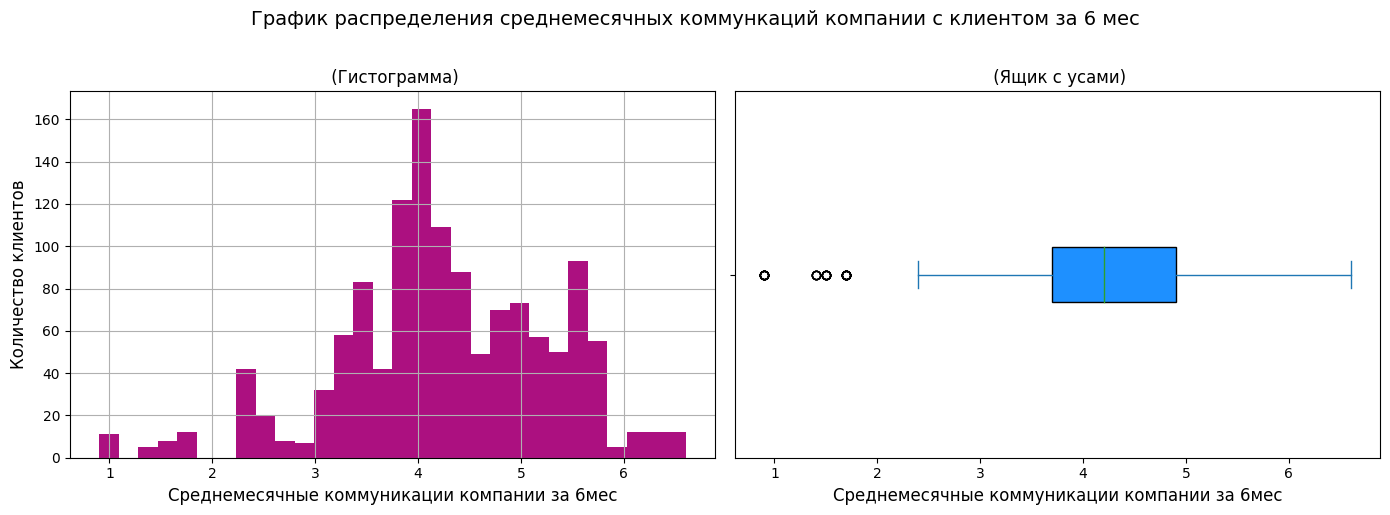

count    1300.000000
mean        4.253769
std         1.014814
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
dtype: float64


In [43]:
b = 'График распределения среднемесячных коммункаций компании с клиентом за 6 мес'
c = 'Среднемесячные коммуникации компании за 6мес'
d = 'Количество клиентов'
e = 30
plotting_graphs_hist(df_market_file['маркет_актив_6_мес'], b, c, d, e)

Значения данного распределения относяться к непрерывным, не похоже на нормальное. За пределами усов ящика наблюдаются выбросы. Медианное значение составляет 4.2ед, стандартное отклонение 1.01ед. Разница между средним и медианным значением небольшая и составляет 0.05ед, что нам говорит о не сильном влиянии выбросов на данные.

* **`'маркет_актив_тек_мес'` & `'маркет_актив_6_мес'` & `'покупательская_активность'`**

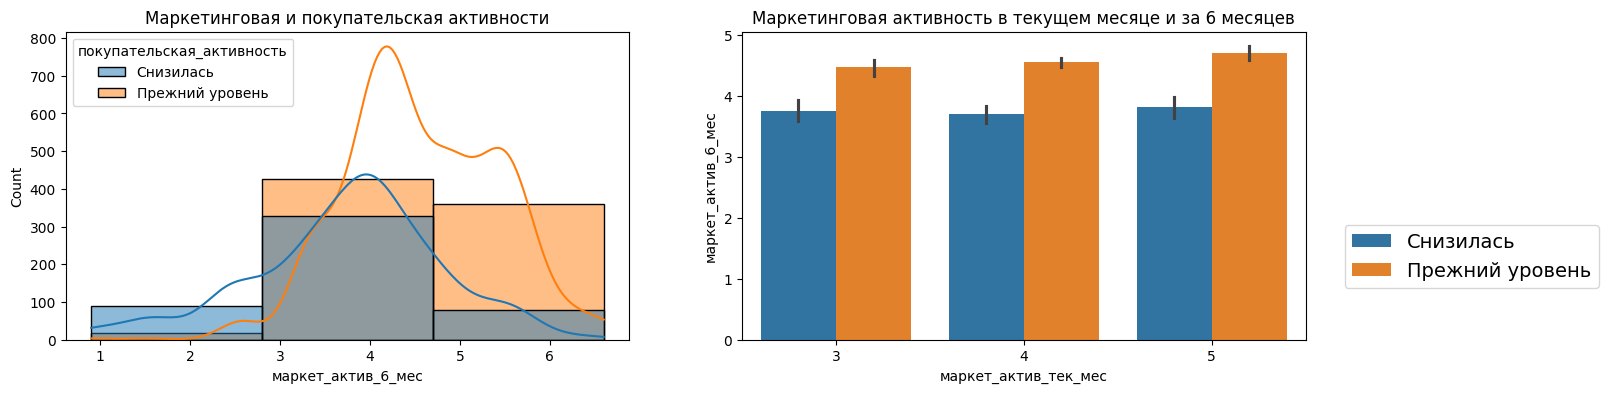

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(data=df_market_file, x='маркет_актив_тек_мес', y='маркет_актив_6_мес',
           hue='покупательская_активность', ax=axes[1])
axes[1].set_title('Маркетинговая активность в текущем месяце и за 6 месяцев')
axes[1].set_xlabel('маркет_актив_тек_мес')
axes[1].set_ylabel('маркет_актив_6_мес')
sns.histplot(df_market_file, bins=3, kde=True, ax=axes[0],
            hue='покупательская_активность', x='маркет_актив_6_мес')
axes[0].set_title('Маркетинговая и покупательская активности')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 0.5), borderaxespad=2, fontsize=14)
plt.show()

* Распределение активности показывает концентрацию в определенных диапазонах, четкое разделение на 3 группы, что может соответствовать уровням 'низкий', 'средний' и 'высокий';
* Группа 'Снизилась' демонстрирует более широкий разброс значений, группа 'Прежний уровень' концентрируется вокруг средних значений;
* Наблюдается устойчивая линейная зависимость: для группы 'Прежний уровень' зависимость более выражена, группа 'Снизилась' показывает меньшую согласованность между текущей и долгосрочной активностью

* **`'маркет_актив_тек_мес'` & `'длительность'` & `'покупательская активность'`**

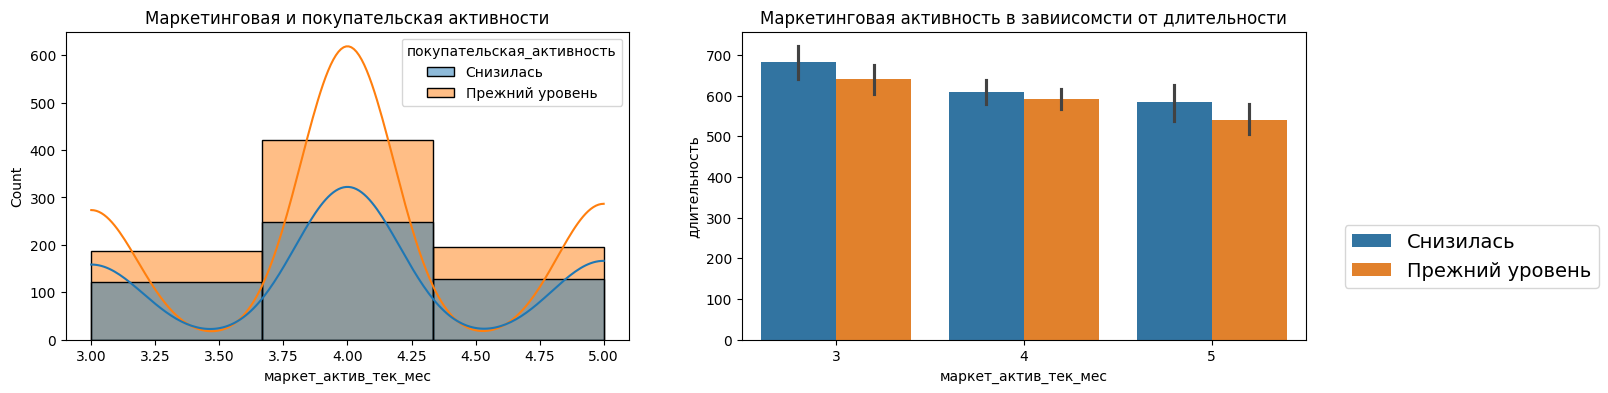

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(data=df_market_file, x='маркет_актив_тек_мес', y='длительность',
           hue='покупательская_активность', ax=axes[1])
axes[1].set_title('Маркетинговая активность в завиисомсти от длительности')
axes[1].set_xlabel('маркет_актив_тек_мес')
axes[1].set_ylabel('длительность')
sns.histplot(df_market_file, bins=3, kde=True, ax=axes[0],
            hue='покупательская_активность', x='маркет_актив_тек_мес')
axes[0].set_title('Маркетинговая и покупательская активности')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 0.5), borderaxespad=2, fontsize=14)
plt.show()

* Данные демонстрируют четкую группировку маркетинговой активности вокруг 3 ключевых уровней
* Оптимальный уровень маркетинговой активности находится в диапазоне 3.75-4.25
* При значениях ниже 3.75 и выше 4.50 наблюдается снижение эффективности
* максимальная длительность наблюдается у группы с маркетинговой активностью 3, минмальная маркетинговая активность равна 5
* наблюдается обратная зависимость длительности от маркетинговой активности
* группа 'Снизилась' имеет более резкие перепады показателей, группа 'Прежний уровень' демонстрирует устойчивость

* **`'длительность'`**

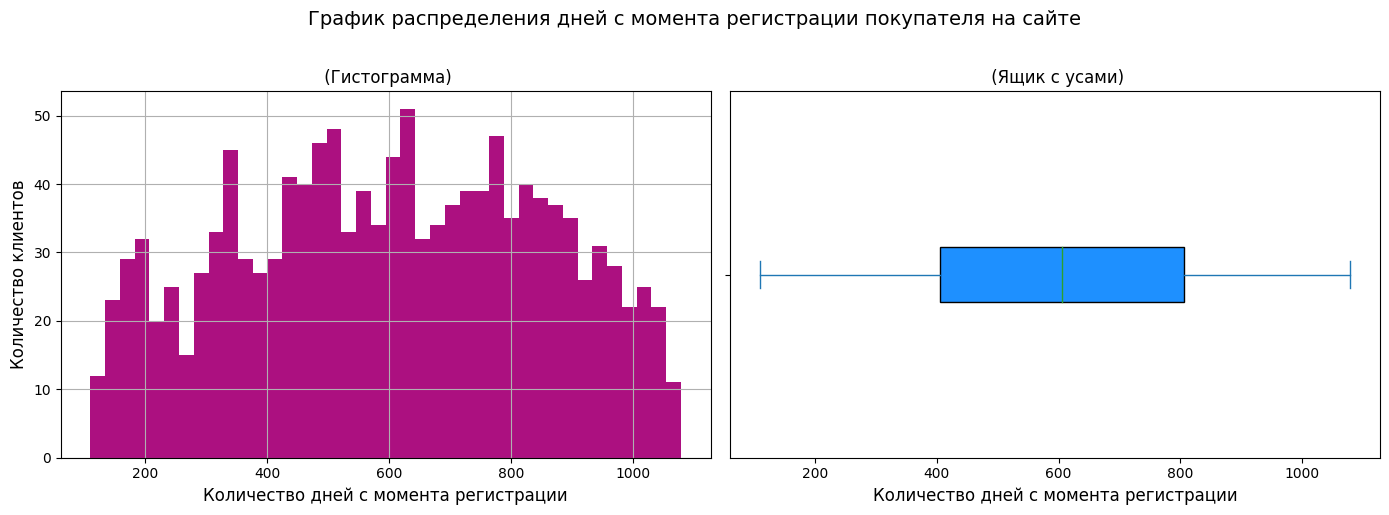

count    1300.000000
mean      601.898462
std       249.856289
min       110.000000
25%       405.500000
50%       606.000000
75%       806.000000
max      1079.000000
dtype: float64


In [46]:
b = 'График распределения дней с момента регистрации покупателя на сайте'
c = 'Количество дней с момента регистрации'
d = 'Количество клиентов'
e = 40
plotting_graphs_hist(df_market_file['длительность'], b, c, d, e)

Значения данного распределения относяться к дискретным не категориальным. Не относится к нормальному распределению. Все точки данных находятся в пределах усов ящика, выбросы отсутствуют. Медианное значение составляет 606 дней с момента регистрации на сайте, стандартное отклонение 249,86д. Разница между средним и медианным значением небольшая и составляет ~4.0д, что нам также говорит об отсутствии выбросов в данных.

* **`'акционные_покупки'`**

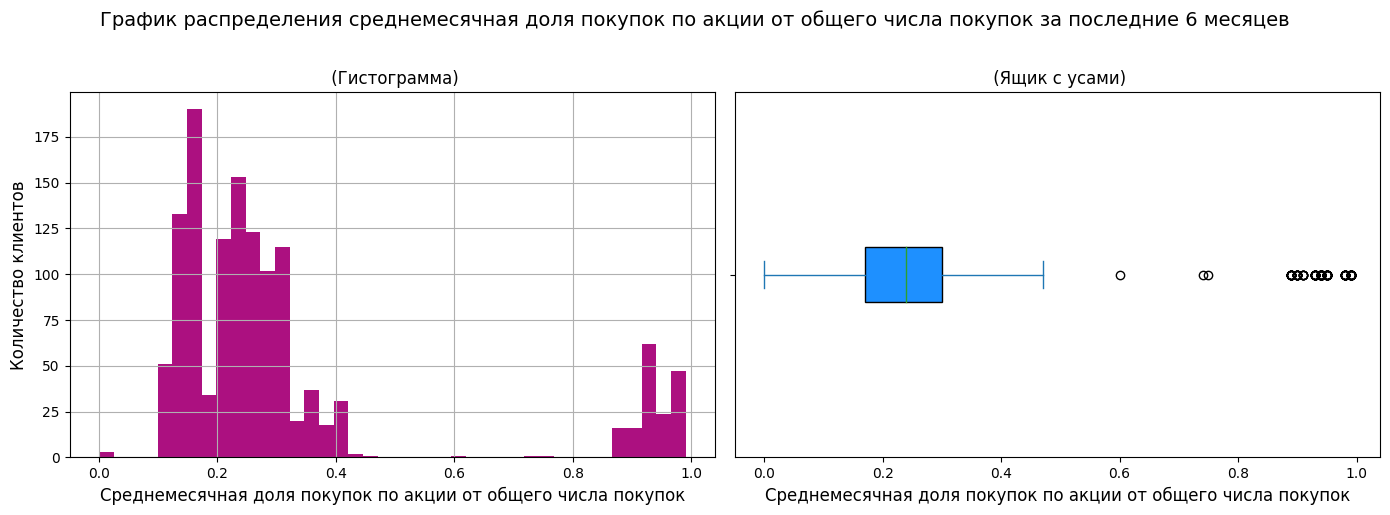

count    1300.000000
mean        0.319808
std         0.249843
min         0.000000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
dtype: float64


In [47]:
b = 'График распределения среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев'
c = 'Среднемесячная доля покупок по акции от общего числа покупок'
d = 'Количество клиентов'
e = 40
plotting_graphs_hist(df_market_file['акционные_покупки'], b, c, d, e)

Значения данного распределения относяться к непрерывным. Наблюдается бимодальность. Имеются точки данных за пределами усов ящика, выбросы присутствуют. Медианное значение составляет 0.24 доля покупок по акции по отношению к общим, стандартное отклонение 0.25. Разница между средним и медианным значением составляет ~0.08, что говорит (как и высокое значение стандартного отклонения) о сильном влиянии выбросов на данные.

* **`'маркет_актив_тек_мес'` & `'акционные_покупки'` & `'покупательская_активность'`**

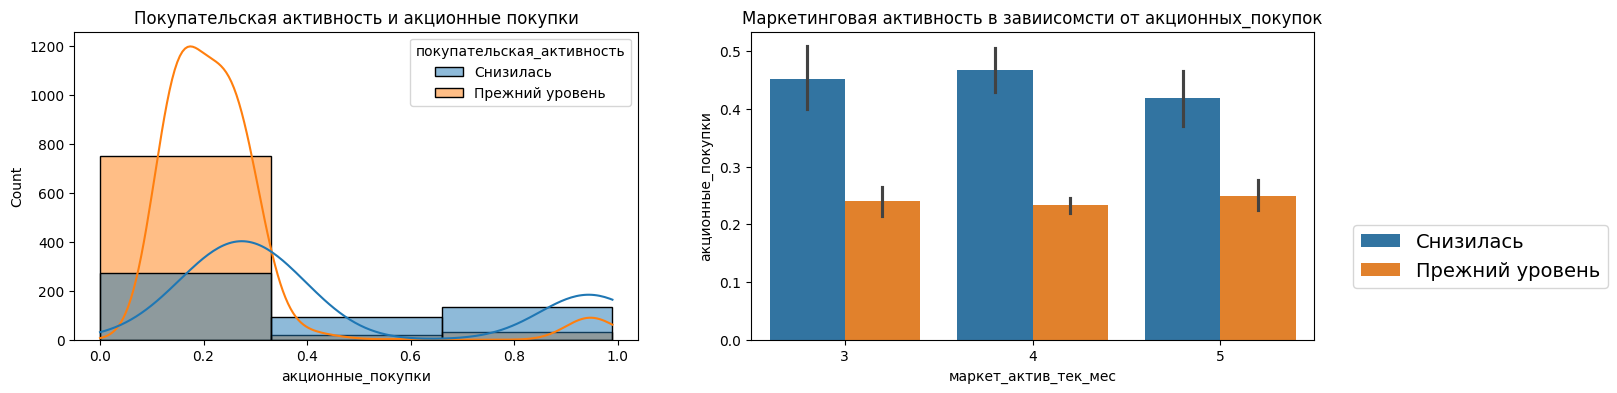

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(data=df_market_file, x='маркет_актив_тек_мес', y='акционные_покупки',
           hue='покупательская_активность', ax=axes[1])
axes[1].set_title('Маркетинговая активность в завиисомсти от акционных_покупок')
axes[1].set_xlabel('маркет_актив_тек_мес')
axes[1].set_ylabel('акционные_покупки')
sns.histplot(df_market_file, bins=3, kde=True, ax=axes[0],
            hue='покупательская_активность', x='акционные_покупки')
axes[0].set_title('Покупательская активность и акционные покупки')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 0.5), borderaxespad=2, fontsize=14)
plt.show()

* Бимодальное распределение данных акционных покупок что может говорить о наличии двух различных групп покупательского поведения, возможном разделении на группы 'редкие' и 'частые' участники акций
* Группа 'Снизилась' демонстрирует более широкий разброс значений, группа 'Прежний уровень' концентрируется вокруг средних значений.<br>

* Пик эффективности маркетинговых активностей находится в среднем диапазоне, чрезмерная активность (>4.5) может приводить к снижению участия в акциях
* Группа 'Прежний уровень' показывает более стабильные результаты, группа 'Снизилась' более чувствительна к изменениям маркетинговой активности

* **`'популярная_категория'`**

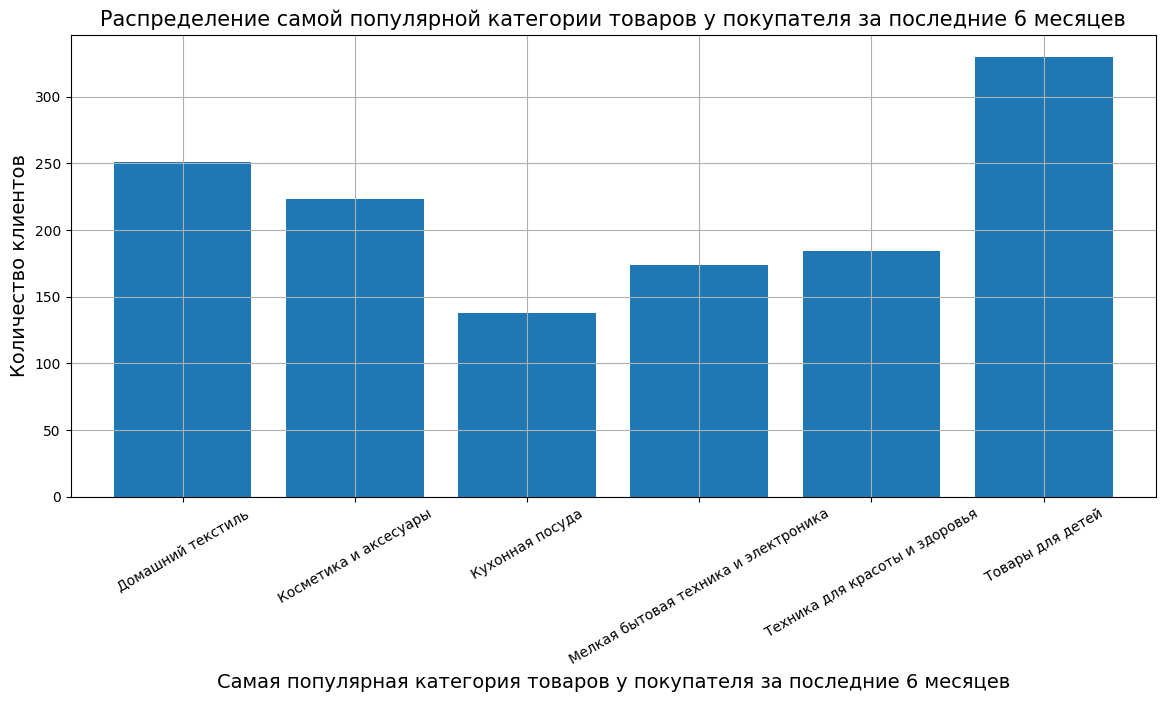

In [49]:
b = 'Распределение самой популярной категории товаров у покупателя за последние 6 месяцев'
c = 'Самая популярная категория товаров у покупателя за последние 6 месяцев'
d = 'Количество клиентов'
plotting_graphs_bar_cat(df_market_file['популярная_категория'], b, c, d)

Значения данного распределения относиться к категориальным. Самая популярная категория - **Товары для детей**, наименее популярная - **Кухонная посуда**.

* **`'маркет_актив_тек_мес'` & `'средний просмотр категорий за визит'` & `'покупательская_активность'`**

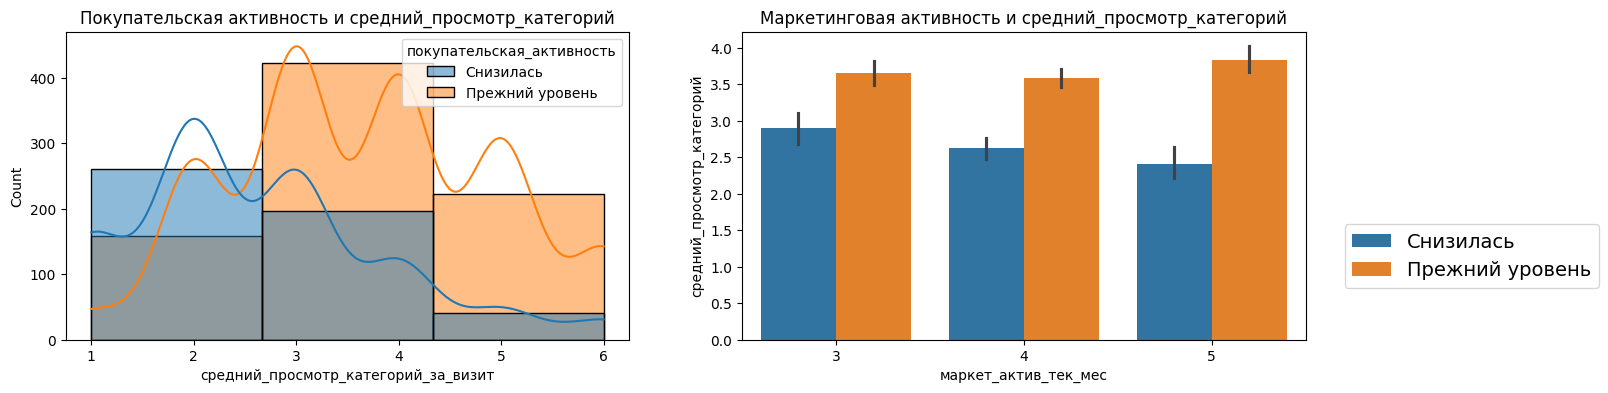

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(data=df_market_file, x='маркет_актив_тек_мес', y='средний_просмотр_категорий_за_визит',
           hue='покупательская_активность', ax=axes[1])
axes[1].set_title('Маркетинговая активность и средний_просмотр_категорий')
axes[1].set_xlabel('маркет_актив_тек_мес')
axes[1].set_ylabel('средний_просмотр_категорий')
sns.histplot(df_market_file, bins=3, kde=True, ax=axes[0],
            hue='покупательская_активность', x='средний_просмотр_категорий_за_визит')
axes[0].set_title('Покупательская активность и средний_просмотр_категорий')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 0.5), borderaxespad=2, fontsize=14)
plt.show()

* Бимодальное распределение просмотров категорий, что указывает на:
    * Наличие двух типов покупательского поведения: поверхностный (1-2 категории) и углубленный (4-5 категорий)
* Группа 'Снизилась' демонстрирует более равномерное распределение, группа 'Прежний уровень' концентрируется вокруг средних значений (3-4 категории)
* Минимум 20% пользователей просматривают ≤2 категории, пик приходится на 3-4 категории за визит
* Максимальный просмотр категорий (4-5) достигается при средних значениях маркетинговой активности (3-4)
* Чрезмерная активность (>5) приводит к снижению интереса к категориям
* Группа 'Прежний уровень' показывает стабильный рост просмотра с ростом активности до оптимума (4), группа 'Снизилась' демонстрирует более резкие колебания

* **`'средний_просмотр_категорий_за_визит'`**

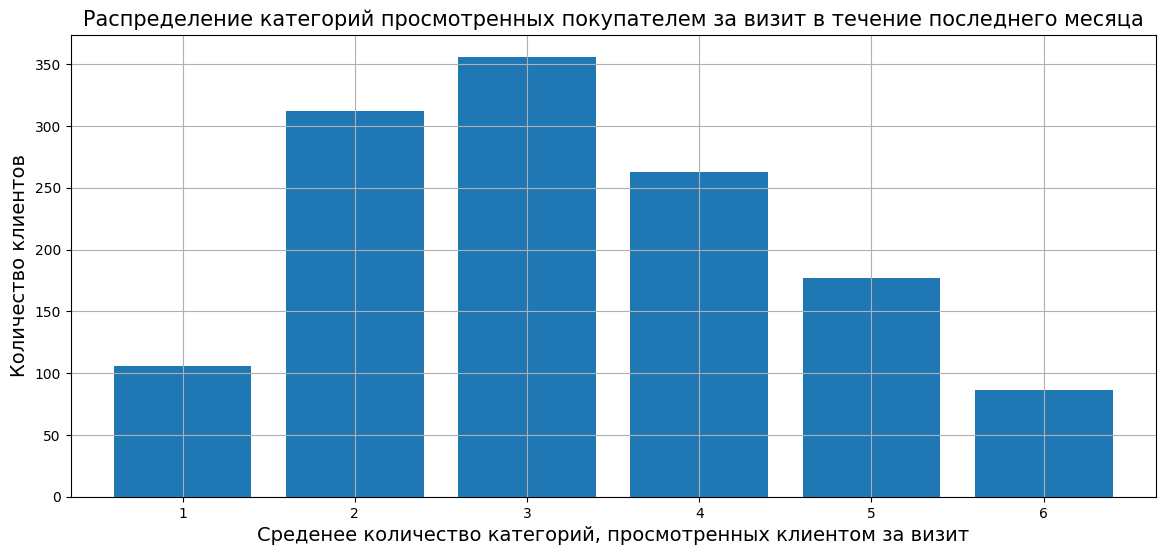

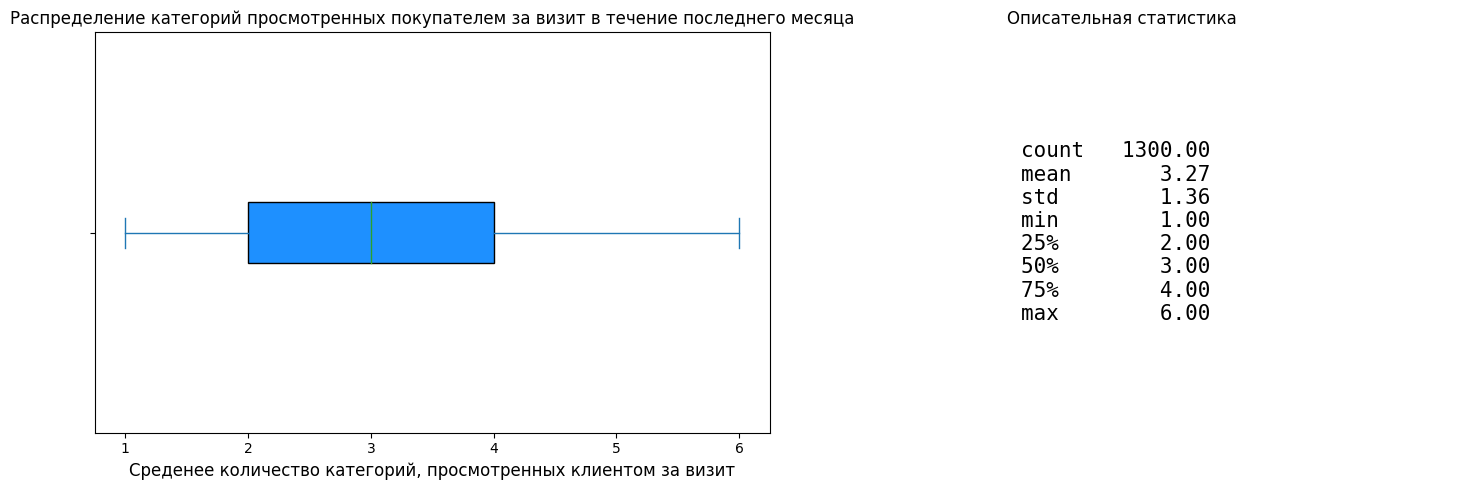

In [51]:
b = 'Распределение категорий просмотренных покупателем за визит в течение последнего месяца'
c = 'Среденее количество категорий, просмотренных клиентом за визит'
d = 'Количество клиентов'
plotting_graphs_bar_num(df_market_file['средний_просмотр_категорий_за_визит'], b, c, d)

Значения данного распределения относяться к дискретным не категориальным. Все точки данных находятся в пределах усов ящика, выбросы отсутствуют. Медианное значение составляет 3 категории просмотренных покупателем за время визита на сайте, стандартное отклонение 1,36д. Разница между средним и медианным значением небольшая и составляет 0.27, что нам также говорит об отсутствии выбросов в данных.

* **`'неоплаченные_продукты_штук_квартал'`**

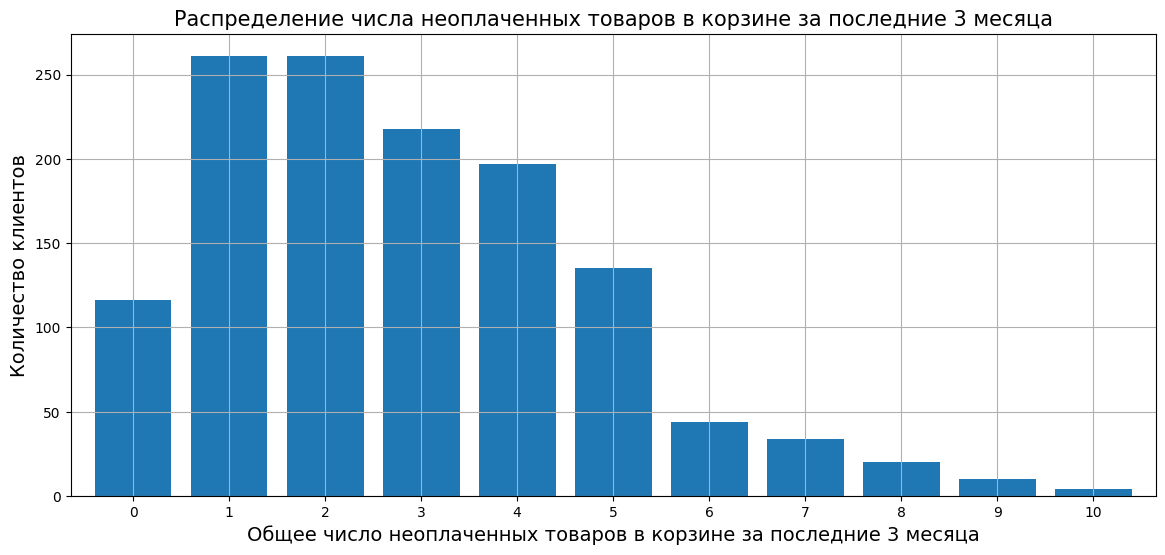

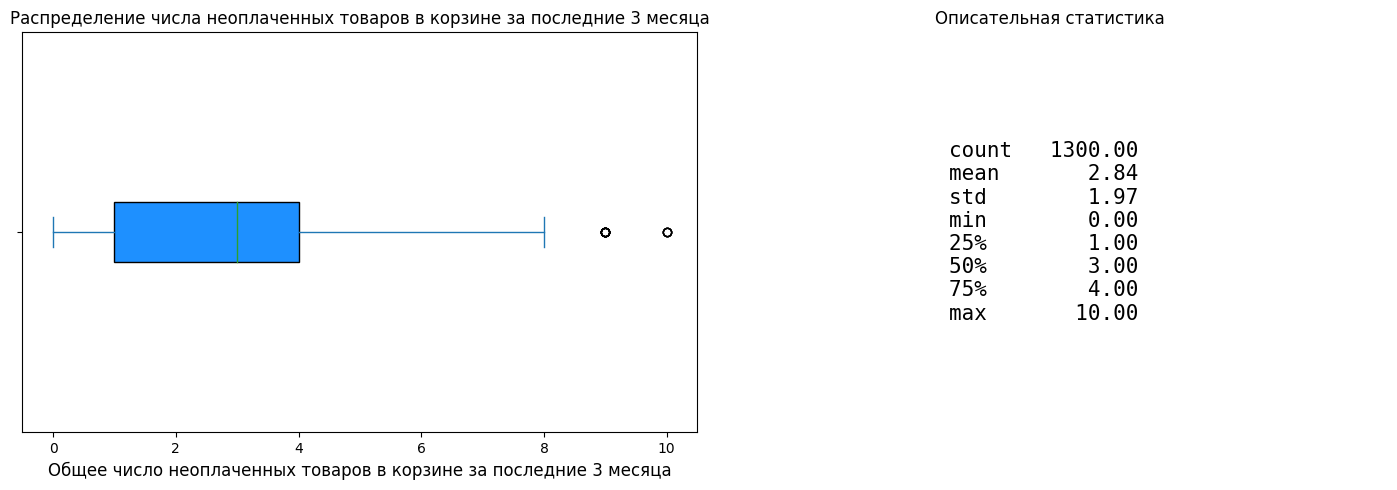

In [52]:
b = 'Распределение числа неоплаченных товаров в корзине за последние 3 месяца'
c = 'Общее число неоплаченных товаров в корзине за последние 3 месяца'
d = 'Количество клиентов'
plotting_graphs_bar_num(df_market_file['неоплаченные_продукты_штук_квартал'], b, c, d)

Значения данного распределения относяться к дискретным не категориальным. Наблюдаются точки данных за пределами усов ящика, выбросы присутствуют. Медианное значение составляет 3 единицы неоплаченных товаров покупателем за последние 3 месяца, стандартное отклонение 1,97ед (большое). Разница между средним и медианным значением небольшая и составляет 0.16.

* **`'покупательская_активность'` & `'неоплаченные_продукты_штук_квартал'`**

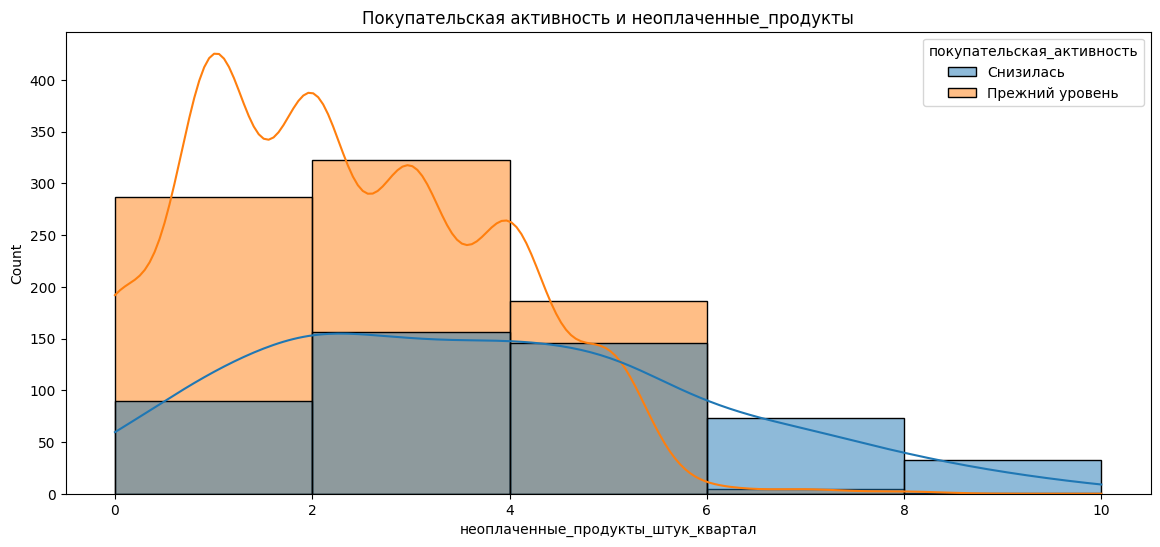

In [53]:
plt.figure(figsize=(14, 6))
sns.histplot(df_market_file, bins=5, kde=True,
            hue='покупательская_активность', x='неоплаченные_продукты_штук_квартал')
plt.title('Покупательская активность и неоплаченные_продукты')
plt.show()

* Распределение имеет правый длинный хвост, большинство значений сосредоточены в диапазоне 0-4 неоплаченных продукта, небольшая часть превышают 6 неоплаченных продуктов
* Группа 'Прежний уровень':
    * пик около 1 неоплаченного продукта, быстрое убывание частоты после 2 продуктов, минимальные значения в "хвосте" распределения
    * Стабильное поведение клиентов, неоплаченные продукты - скорее случайность, чем система
* Группа "Снизилась":
    * Более пологое распределение, значительная доля случаев с 3+ неоплаченными продуктами
    * Сохраняются случаи даже при 8-10 неоплаченных продуктах
    * Серьезные проблемы с завершением покупок, возможные причины:
        * Сложный процесс оплаты;
        * Неадекватные условия доставки;
        * Финансовые трудности клиентов

* **`'ошибка_сервиса'`**

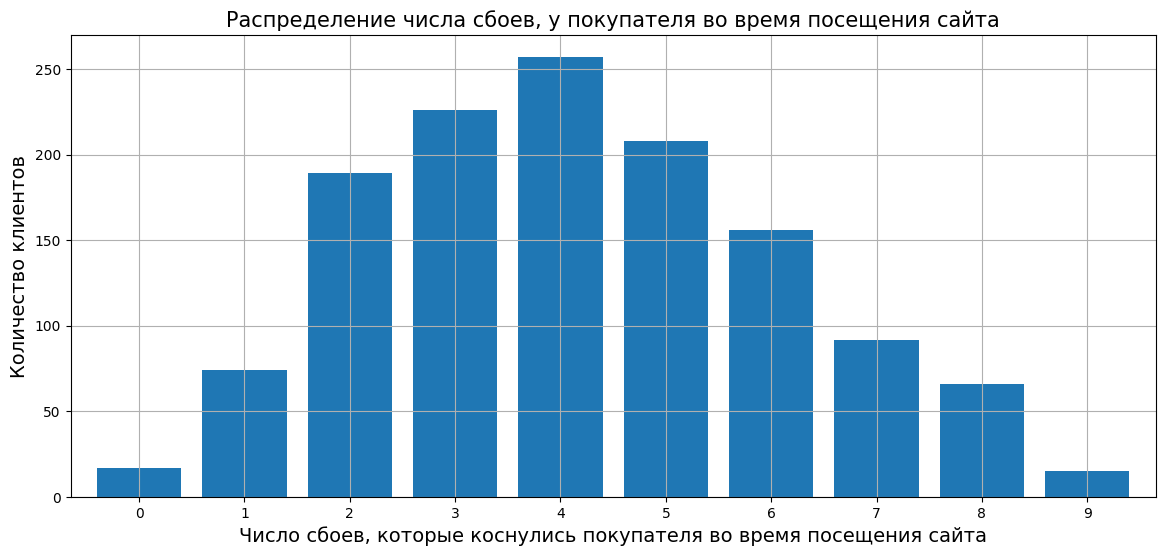

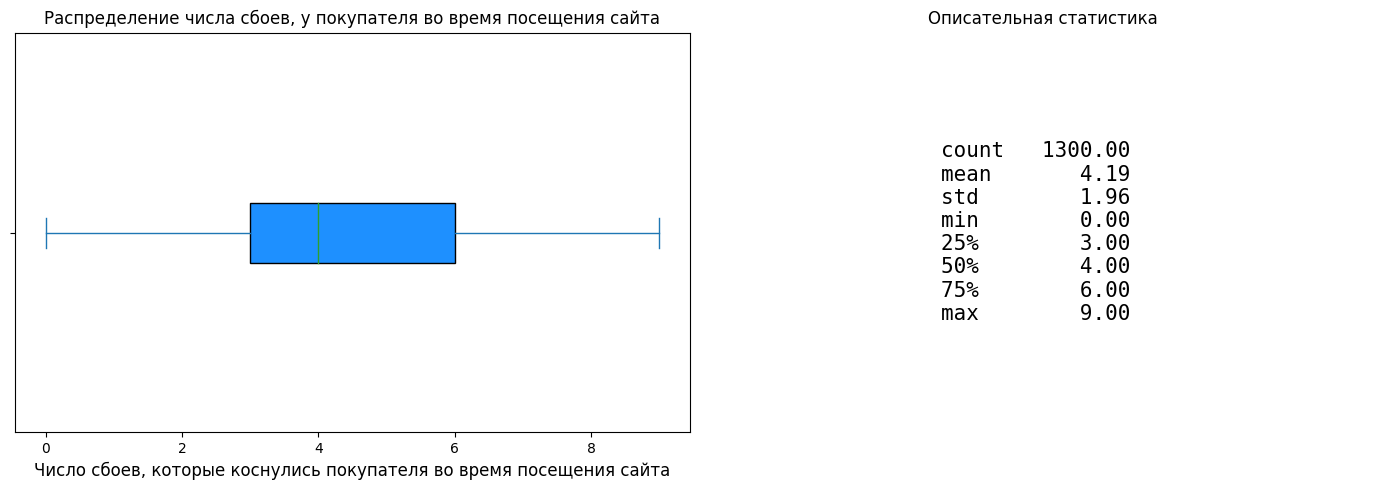

In [54]:
b = 'Распределение числа сбоев, у покупателя во время посещения сайта'
c = 'Число сбоев, которые коснулись покупателя во время посещения сайта'
d = 'Количество клиентов'
plotting_graphs_bar_num(df_market_file['ошибка_сервиса'], b, c, d)

Значения данного распределения относяться к дискретным не категориальным. Все точки данных находятся в пределах усов ящика, выбросы отсутствуют. Медианное значение составляет 4 ошибки сервиса во время посещения сайта покупателем, стандартное отклонение 1,96д. Разница между средним и медианным значением небольшая и составляет 0.19, что нам также говорит об отсутствии выбросов в данных.

* **`'покупательская_активность'` & `'ошибки сервиса'` & `'длительность'`**

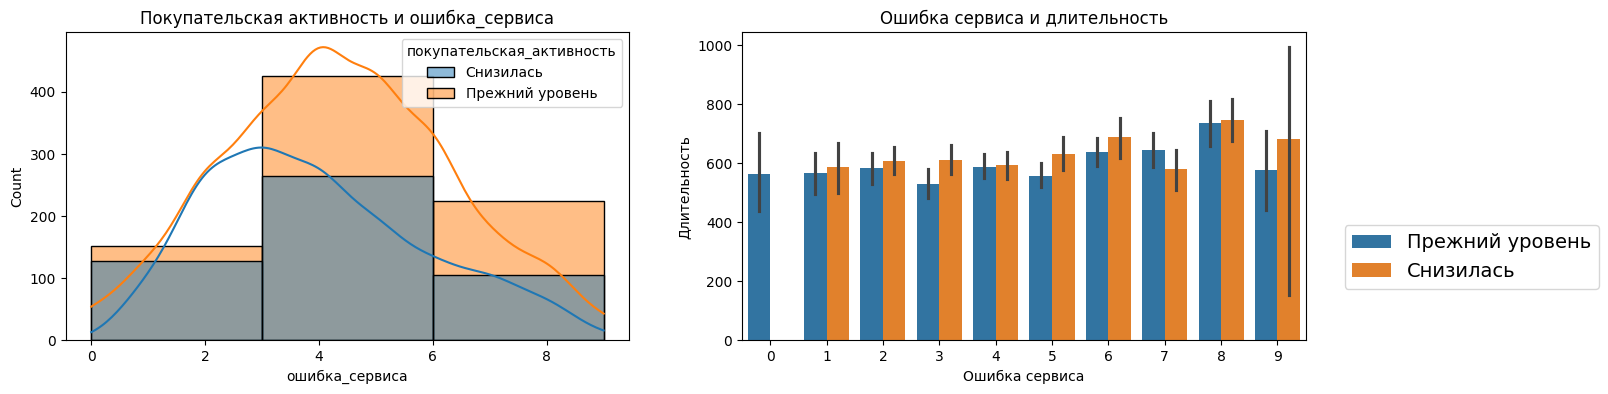

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(data=df_market_file, x='ошибка_сервиса', y='длительность',
           hue='покупательская_активность', ax=axes[1])
axes[1].set_title('Ошибка сервиса и длительность')
axes[1].set_xlabel('Ошибка сервиса')
axes[1].set_ylabel('Длительность')
sns.histplot(df_market_file, bins=3, kde=True, ax=axes[0],
            hue='покупательская_активность', x='ошибка_сервиса')
axes[0].set_title('Покупательская активность и ошибка_сервиса')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 0.5), borderaxespad=2, fontsize=14)
plt.show()

* 'Прежний уровень':
    * Небольшой перевес в первом бине, меньше случаев в крайнем правом бине
    * Более стабильная реакция на ошибки, меньший разброс значений длительности
* 'Снизилась':
    * Чаще встречается в области средних и высоких значений ошибок, более 'динный хвост' распределения
    * Отсутствие выраженного пика вблизи нуля означает, что отсутствие ошибок — не типичная ситуация, проблемы сервиса носят массовый характер, а не единичный
    * Сильнее страдает от множественных ошибок, при 3+ ошибках демонстрирует экстремальные значения длительности
    * При 3+ ошибках демонстрирует экстремальные значения длительности, после этого клиенты тратят значительно больше времени на преодоление трудностей

* **`'страниц_за_визит'`**

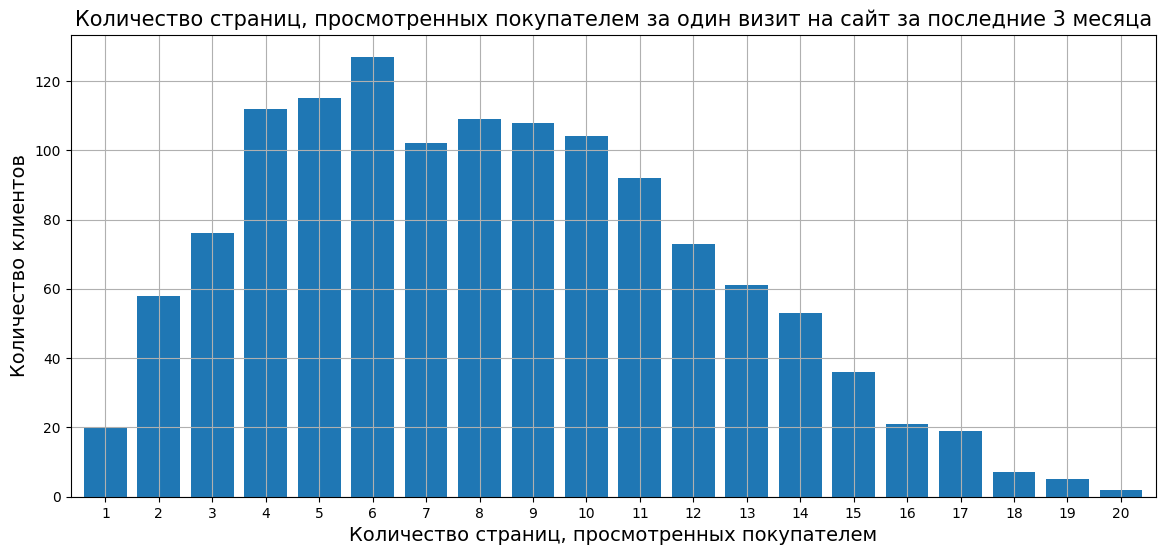

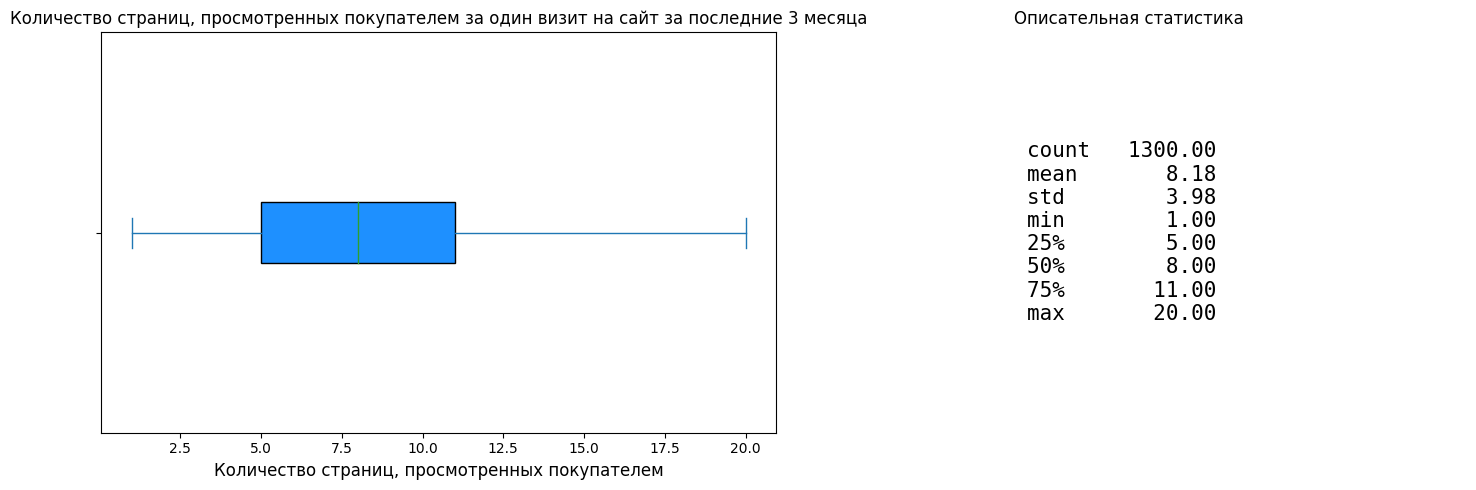

In [56]:
b = 'Количество страниц, просмотренных покупателем за один визит на сайт за последние 3 месяца'
c = 'Количество страниц, просмотренных покупателем'
d = 'Количество клиентов'
plotting_graphs_bar_num(df_market_file['страниц_за_визит'], b, c, d)

Значения данного распределения относяться к дискретным не категориальным. Все точки данных находятся в пределах усов ящика, выбросы отсутствуют. Медианное значение составляет 8 страниц, просмотренных покупателем за один визит на сайт за последние 3 месяца, стандартное отклонение 3,98д. Разница между средним и медианным значением небольшая и составляет 0.18, что нам также говорит об отсутствии выбросов в данных.

* **`'покупательская_активность'` & `'ошибки сервиса'` & `'страниц за визит'`**

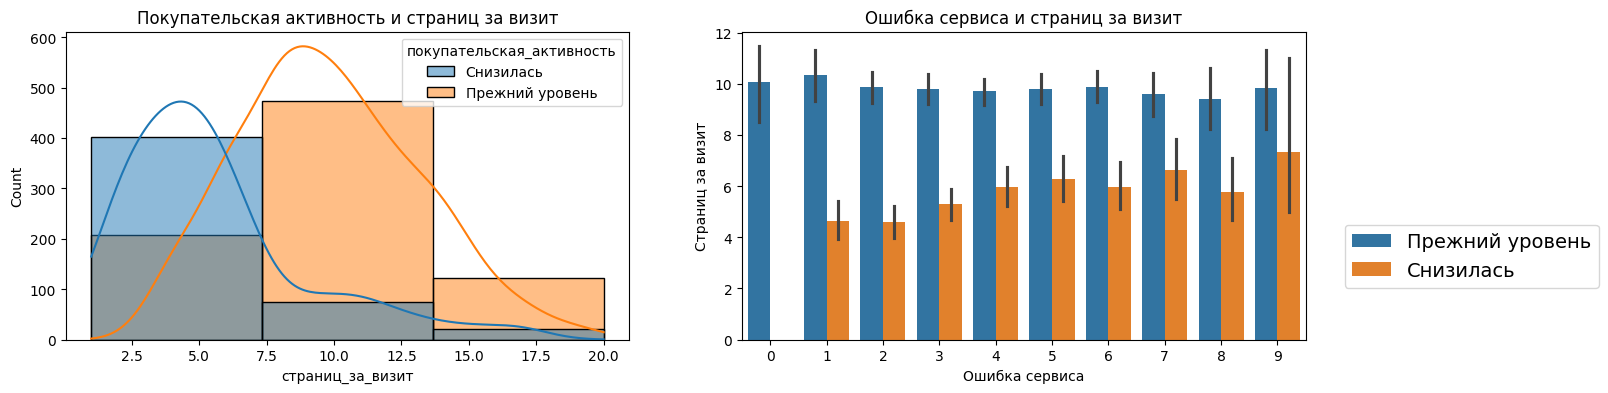

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(data=df_market_file, x='ошибка_сервиса', y='страниц_за_визит',
           hue='покупательская_активность', ax=axes[1])
axes[1].set_title('Ошибка сервиса и страниц за визит')
axes[1].set_xlabel('Ошибка сервиса')
axes[1].set_ylabel('Страниц за визит')
sns.histplot(df_market_file, bins=3, kde=True, ax=axes[0],
            hue='покупательская_активность', x='страниц_за_визит')
axes[0].set_title('Покупательская активность и страниц за визит')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 0.5), borderaxespad=2, fontsize=14)
plt.show()

* Данные имеют положительную асимметрию (длинный хвост справа)
* Основная масса визитов приходится на 4-8 страниц, меньшая часть - короткие визиты (1-3 страницы)
* 'Прежний уровень':
    * Пик в зоне 7-9 страниц, более компактное распределение, меньше экстремальных значений
    * Более устойчивое поведение, меньше реагируют на ошибки
* 'Снизилась':
    * Шире разброс значений, больше случаев как очень коротких (<3), так и очень длинных (>10) сессий
    * Двугорбое распределение (возможно 2 подгруппы)
    * Сильнее сокращают активность при ошибках, больше случаев полного прекращения сессии
* При 1-2 ошибках: рост просмотра страниц
    * Пользователи пытаются найти альтернативные пути
* При 3+ ошибках: резкое сокращение просмотра
    * Разочарование и выход с сайта

#### Далее по порядку датасет **`'df_market_money'`**:

* проанализируем распределение значений признака **`'выручка'`** по всему датасету;
* проанализируем признак **`'выручка'`** суммарно за каждый период (динамика);
* проанализируем распределение значений признака **`'выручка'`** после группировки по периодам с наложением графиков, а также посмотрим на 'ящик с усами' после группировки по периодам

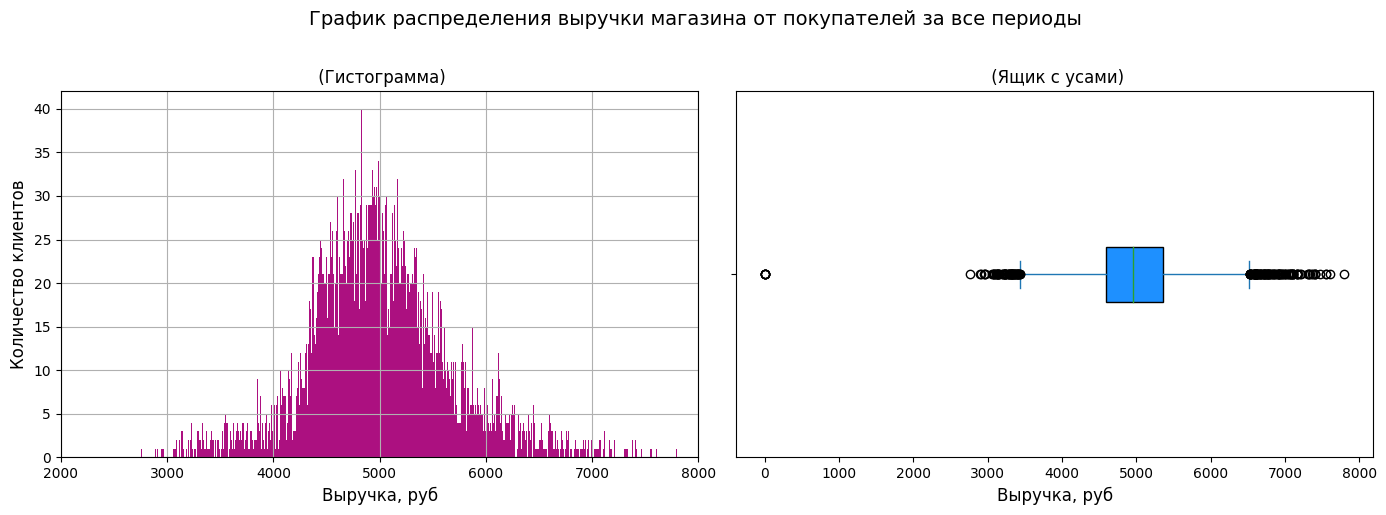

count    3899.00000
mean     4999.57743
std       706.99988
min         0.00000
25%      4590.10000
50%      4957.00000
75%      5363.00000
max      7799.40000
dtype: float64


In [58]:
b = 'График распределения выручки магазина от покупателей за все периоды'
c = 'Выручка, руб'
d = 'Количество клиентов'
e = 800
plotting_graphs_hist(df_market_money['выручка'], b, c, d, e, xlim=(2000, 8000))

Распределение данных визуально очень похоже на 'колокол' нормального распределения. Медианное значение составляет 4957.5 руб, стандартное отклонение 706.9руб, среднее значение незначительно отличается от медианного на 58.0 руб, что говорит о минимальном влиянии на данные. На данном графике представлены данные выручки за все периоды. Далее рассмотрим данные после группировке по периодам.

C:\Users\admin\AppData\Local\Temp\ipykernel_16564\878439691.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_market_money['период'] = pd.Categorical(
C:\Users\admin\AppData\Local\Temp\ipykernel_16564\878439691.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_market_money.groupby('период')['выручка'].sum().sort_index().plot(
C:\Users\admin\AppData\Local\Temp\ipykernel_16564\878439691.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beh

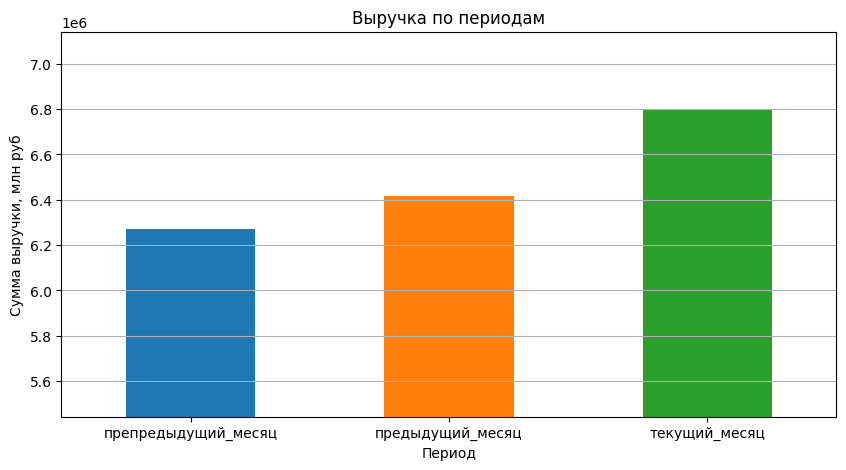

In [59]:
period_order = ['препредыдущий_месяц', 'предыдущий_месяц', 'текущий_месяц']

df_market_money['период'] = pd.Categorical(
    df_market_money['период'], 
    categories=period_order, 
    ordered=True
)

df_market_money.groupby('период')['выручка'].sum().sort_index().plot(
    kind='bar', 
    title='Выручка по периодам',
    figsize=(10, 5),
    color=['#1f77b4', '#ff7f0e', '#2ca02c'] 
)
max_value = df_market_money.groupby('период')['выручка'].sum().sort_index().max()
plt.ylim(max_value * 0.8, max_value * 1.05)
plt.xlabel('Период')
plt.ylabel('Сумма выручки, млн руб')
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.show()

По суммарным данным выручки с группировкой по периодам можно сказать о растущей динамике. То есть выручка на рассматриваемом промежутке времени растет. Это может быть связанно с сезонностью. Даже если активность покупателей по предположению компании падает, у выручки положительная динамика.

C:\Users\admin\AppData\Local\Temp\ipykernel_16564\3950090074.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_market_money['период'] = pd.Categorical(


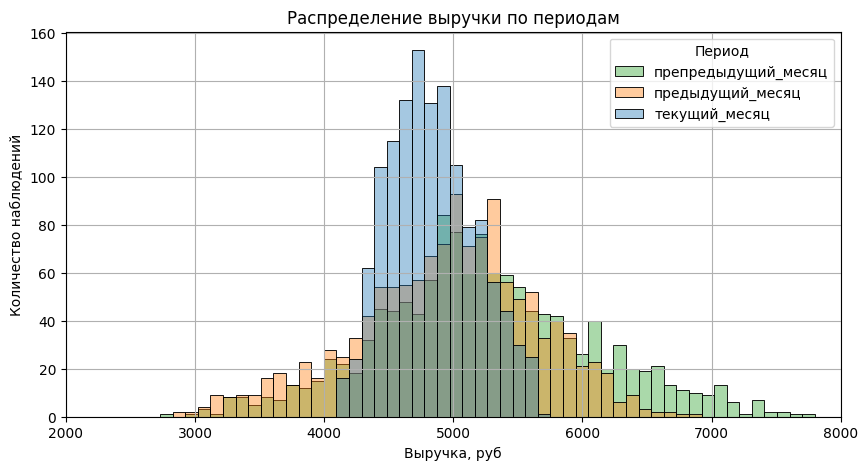

In [60]:
period_order = ['препредыдущий_месяц', 'предыдущий_месяц', 'текущий_месяц']
df_market_money['период'] = pd.Categorical(
    df_market_money['период'], 
    categories=period_order, 
    ordered=True
)

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_market_money,
    x='выручка',
    hue='период',
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'],
    alpha=0.4,
    multiple='layer'
)
plt.grid()
plt.xlim(2000, 8000)
plt.legend(
    title='Период',
    labels=period_order,
    loc='upper right'
)

plt.title('Распределение выручки по периодам')
plt.xlabel('Выручка, руб')
plt.ylabel('Количество наблюдений')
plt.show()

На рассматриваемых распределениях выручки после группировки по периодам с наложением, можно сказать что нет ни одного близкого к нормальному. Значения группируются в основном около 5000 руб.

C:\Users\admin\AppData\Local\Temp\ipykernel_16564\564927752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


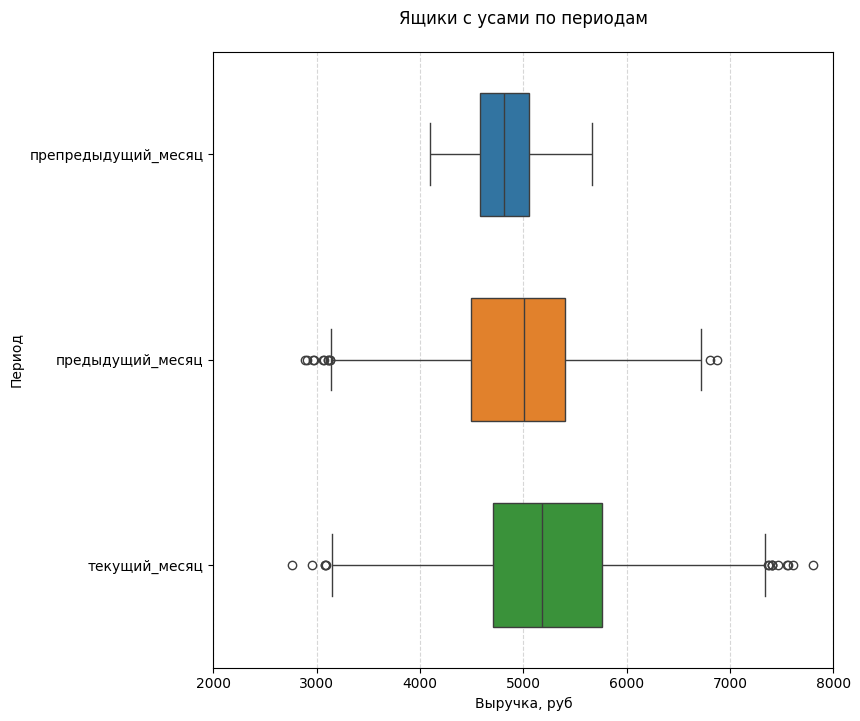

In [61]:
plt.figure(figsize=(8, 8))

sns.boxplot(
    data=df_market_money,
    y='период', 
    x='выручка', 
    order=['препредыдущий_месяц', 'предыдущий_месяц', 'текущий_месяц'],
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'],
    width=0.6,
    orient='h'
)

plt.xlim(2000, 8000)
plt.title('Ящики с усами по периодам', pad=20)
plt.xlabel('Выручка, руб')
plt.ylabel('Период')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

По 'ящикам с усами', после группировки по периодам видно что медианное значение выручки увеличивается. Также наблюдаются появление выбросов в данных выручки в обе стороны, что может говорить о появлении разнообразных ценовых покупок, как более дешевых по отношению к медианной цене, так и более дорогостоящих.

#### Далее по порядку датасет **`'df_market_time'`**

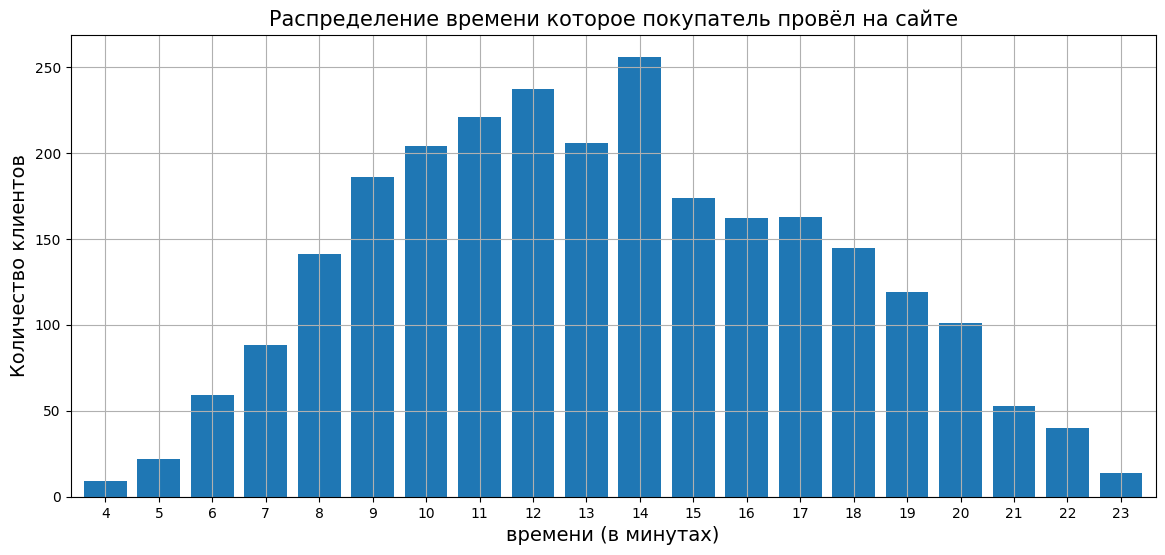

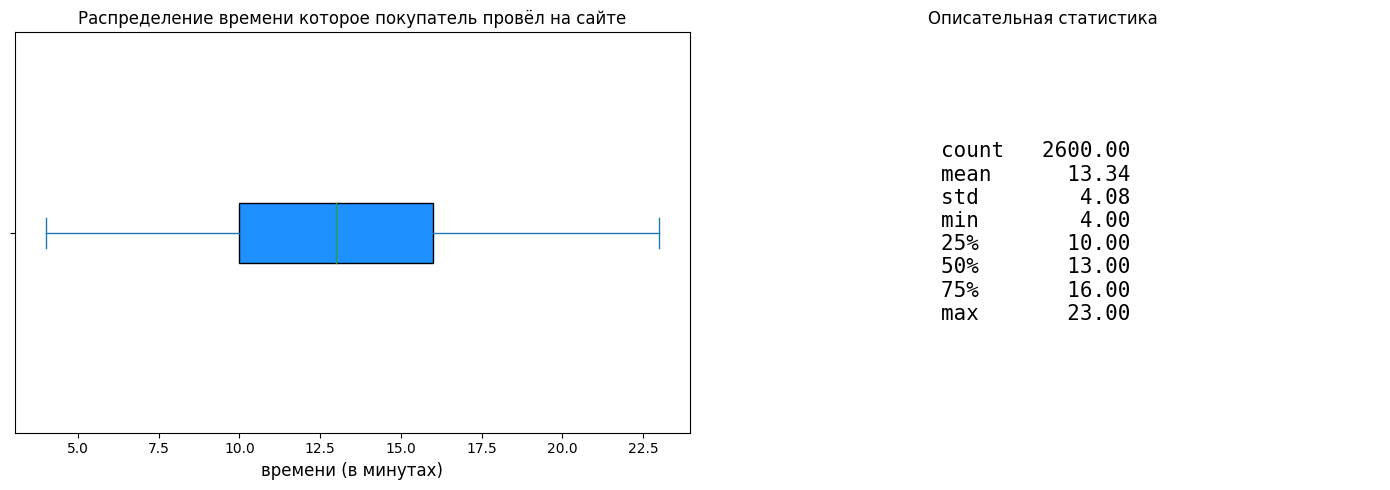

In [62]:
b = 'Распределение времени которое покупатель провёл на сайте'
c = 'времени (в минутах)'
d = 'Количество клиентов'
plotting_graphs_bar_num(df_market_time['минут'], b, c, d)#, xlim=(2000, 8000))

На данном распределении по всем периодам вместе мы наблюдаем график визуально схож на колокообразное, дискретное распределение. Судя по 'ящику с усами' выбросы отсутствуют. Медианное значение времени составляет 13 минут, среднее 13.34, стандартное отклонение 4.08.

C:\Users\admin\AppData\Local\Temp\ipykernel_16564\3608496352.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_market_time.groupby('период')['минут'].sum().sort_index().plot(
C:\Users\admin\AppData\Local\Temp\ipykernel_16564\3608496352.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_value = df_market_time.groupby('период')['минут'].sum().sort_index().max()


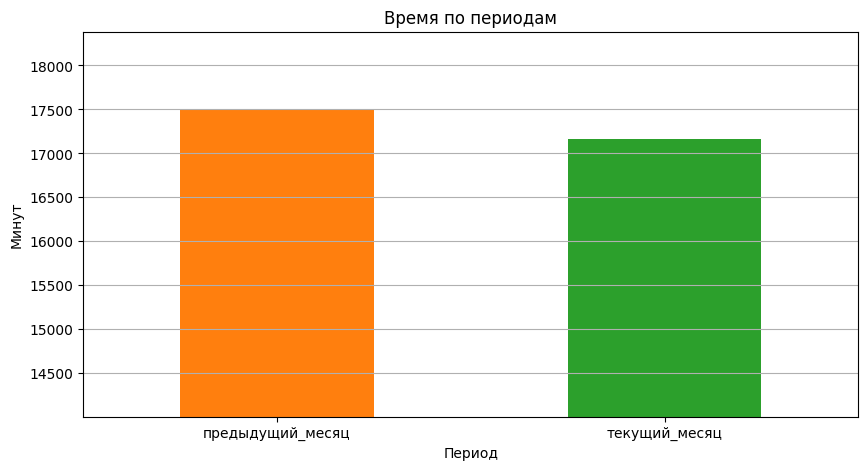

In [63]:
period_order = ['предыдущий_месяц', 'текущий_месяц']

df_market_time['период'] = pd.Categorical(
    df_market_time['период'], 
    categories=period_order, 
    ordered=True
)

df_market_time.groupby('период')['минут'].sum().sort_index().plot(
    kind='bar', 
    title='Время по периодам',
    figsize=(10, 5),
    color=['#ff7f0e', '#2ca02c'] 
)
max_value = df_market_time.groupby('период')['минут'].sum().sort_index().max()
plt.ylim(max_value * 0.8, max_value * 1.05)
plt.xlabel('Период')
plt.ylabel('Минут')
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.show()

По данной столбчатой диаграмме можно сказать что динамика проводимого времени на сайте идет на небольшое снижение, что также можно связать с сезонностью. По данной диаграмме можно предположить, что активность по времени снижается незначительно, несмотря на это как мы видили выше, выручка растет. Возможно это также связанно с постоянными покупателями, которым не нужно много времени для совершения заказа на сайте.

C:\Users\admin\AppData\Local\Temp\ipykernel_16564\2610228158.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


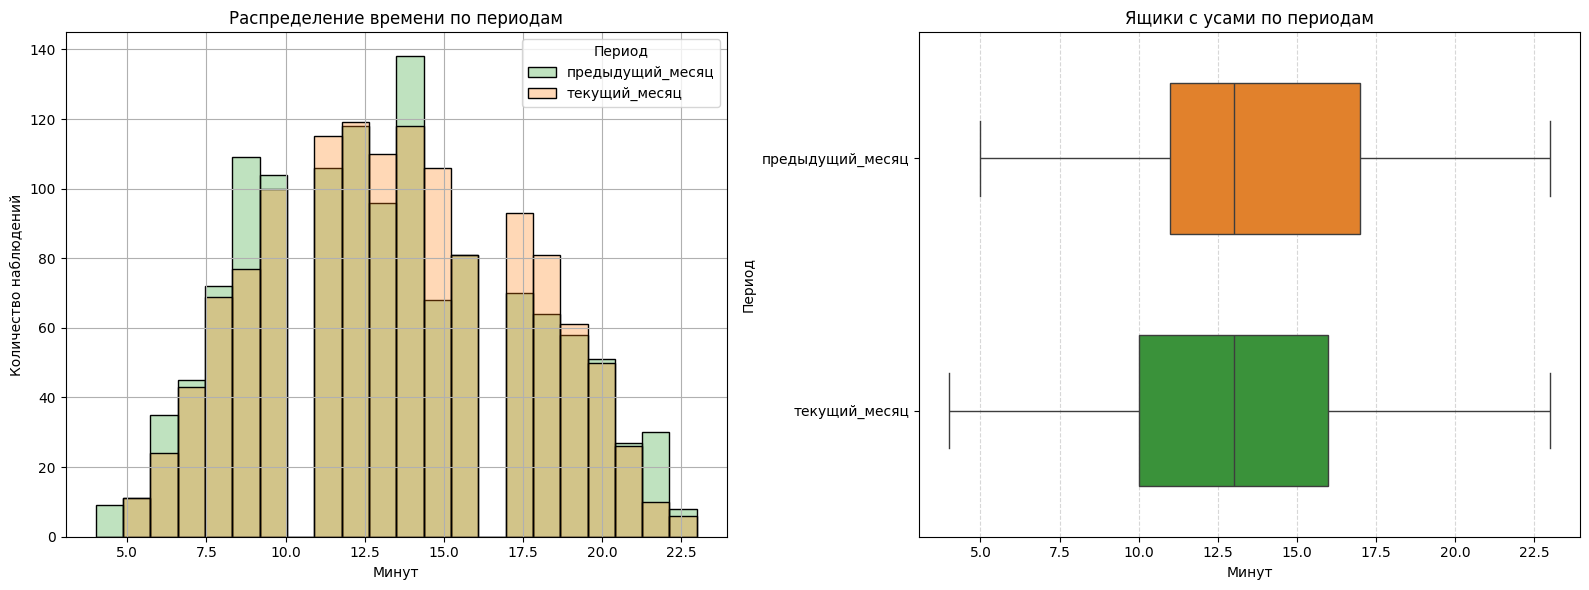

In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=df_market_time,
    x='минут',
    hue='период',
    palette=['#ff7f0e', '#2ca02c'],
    alpha=0.3,
    multiple='layer',
    ax=ax1
)
ax1.set_title('Распределение времени по периодам')
ax1.set_xlabel('Минут')
ax1.set_ylabel('Количество наблюдений')
ax1.grid()
ax1.legend(
    title='Период',
    labels=period_order,
    loc='upper right'
)

sns.boxplot(
    data=df_market_time,
    y='период',
    x='минут',
    order=['предыдущий_месяц', 'текущий_месяц'],
    palette=['#ff7f0e', '#2ca02c'],
    width=0.6,
    orient='h',
    ax=ax2
)
ax2.set_title('Ящики с усами по периодам')
ax2.set_xlabel('Минут')
ax2.set_ylabel('Период')
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Здесь мы видим что после группировки наложенные распределения времени, проведенного на сайте покупателями сильно не отличается, медианные практически совпадают. По гистограмме людей по трате времени можно поделить на 3 категории: до 10мин, от 10 до 16мин, и от 16 до 23мин. 

#### Далее по порядку датасет **`'df_money_mean'`**

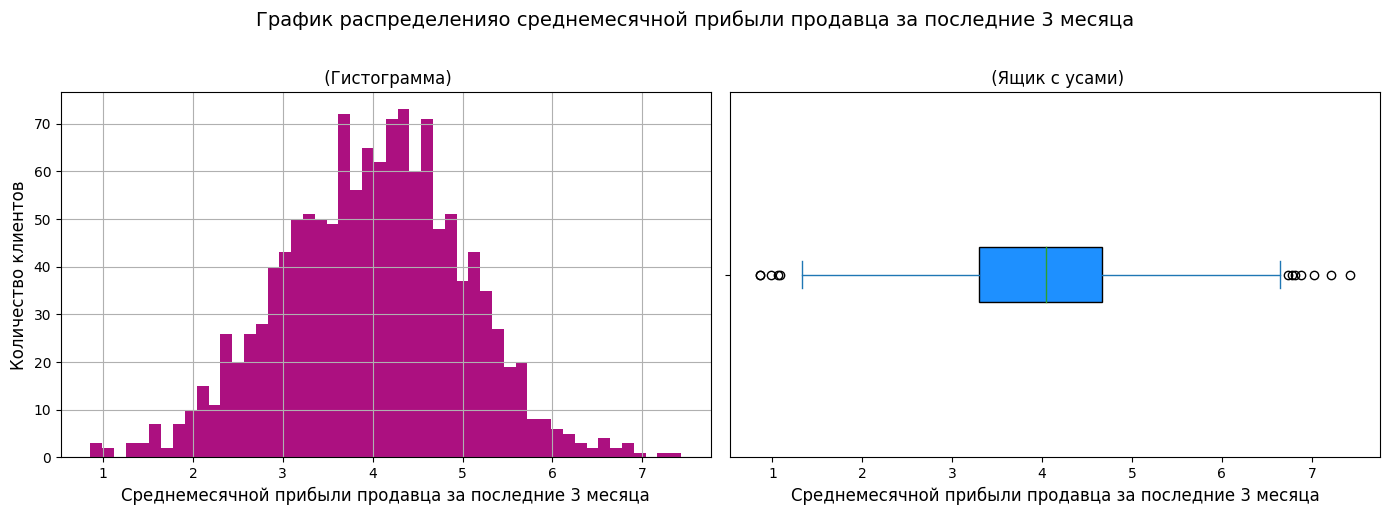

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
dtype: float64


In [65]:
b = 'График распределенияо среднемесячной прибыли продавца за последние 3 месяца'
c = 'Среднемесячной прибыли продавца за последние 3 месяца'
d = 'Количество клиентов'
e = 50
plotting_graphs_hist(df_money_mean['прибыль'], b, c, d, e)

Распределение данных визуально очень похоже на 'колокол' нормального распределения, однако здесь присутствует выбросы, его также видно на диаграмме 'ящик с усами'. Медианное значение составляет 4045 руб, стандартное отклонение 1013руб, среднее значение незначительно отличается от медианного на 49 руб, что говорит о минимальном влиянии на данные.

Отберем клиентов с покупательской активностью не менее 3х месяцев.

In [66]:
df_pivot = df_market_money.pivot_table(index='id', columns='период', values='выручка', aggfunc='sum')
df_pivot.columns = ['препредыдущий_месяц_выручка', 'предыдущий_месяц_выручка', 'текущий_месяц_выручка']
len(df_pivot)

C:\Users\admin\AppData\Local\Temp\ipykernel_16564\87417112.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivot = df_market_money.pivot_table(index='id', columns='период', values='выручка', aggfunc='sum')


1300

In [67]:
df_pivot.head()

,препредыдущий_месяц_выручка,предыдущий_месяц_выручка,текущий_месяц_выручка
id,,,
215348,0.0,0.0,3293.1
215349,4472.0,5216.0,4971.6
215350,4826.0,5457.5,5058.4
215351,4793.0,6158.0,6610.4
215352,4594.0,5807.5,5872.5


In [68]:
df_activ_pivot = df_pivot[
    (df_pivot['препредыдущий_месяц_выручка'] > 0) & 
    (df_pivot['предыдущий_месяц_выручка'] > 0) & 
    (df_pivot['текущий_месяц_выручка'] > 0)]

len(df_activ_pivot)

1296

Посредством группировки данных по `'id'` преобразовали таблицу с данными **`'market_money'`**, и получили датасет с 4мя колонками, где указана выручка с учетом периода. Применили фильтрацию, отобрав клиентов, которые проявляли активность в течении поседних 3х месяцев. В итоге у нас осталось 1296 клиентов.

### Промежуточный вывод

На данном этапе мы провели исследовательский анализ данных:
1. Провели статистический анализ всех признаков. Построили графики для каждого признака.
    * Для этого были написаны функции, которые строют графики распределения.
        * Первая функция строит графики ('hist' и 'boxplot') для числовых непрерывных значений;
        * Вторая, третья и четвертая функции для дискретных или категорийных значений ('barplot' и 'boxplot');
        * Пятая функция строит диаграммы для бинарных признаков.
    * Также применялись другие методы графического анализа
2. **`'маркет_актив_тек_мес'` & `'маркет_актив_6_мес'` & `'покупательская_активность'`**
    * Распределение активности показывает концентрацию в определенных диапазонах, четкое разделение на 3 группы, что может соответствовать уровням 'низкий', 'средний' и 'высокий';
    * Группа 'Снизилась' демонстрирует более широкий разброс значений, группа 'Прежний уровень' концентрируется вокруг средних значений;
    * Наблюдается устойчивая линейная зависимость: для группы 'Прежний уровень' зависимость более выражена, группа 'Снизилась' показывает меньшую согласованность между текущей и долгосрочной активностью
3. **`'маркет_актив_тек_мес'` & `'длительность'` & `'покупательская активность'`**
    * Данные демонстрируют четкую группировку маркетинговой активности вокруг 3 ключевых уровней
    * Оптимальный уровень маркетинговой активности находится в диапазоне 3.75-4.25
    * При значениях ниже 3.75 и выше 4.50 наблюдается снижение эффективности
    * максимальная длительность наблюдается у группы с маркетинговой активностью 3, минимальная маркетинговая активность равна 5
    * наблюдается обратная зависимость длительности от маркетинговой активности
    * группа 'Снизилась' имеет более резкие перепады показателей, группа 'Прежний уровень' демонстрирует устойчивость 
4. **`'маркет_актив_тек_мес'` & `'акционные_покупки'` & `'покупательская_активность'`**
    * Бимодальное распределение данных акционных покупок что может говорить о наличии двух различных групп покупательского поведения, возможном разделении на группы 'редкие' и 'частые' участники акций
    * Группа 'Снизилась' демонстрирует более широкий разброс значений, группа 'Прежний уровень' концентрируется вокруг средних значений.<br>
    * Пик эффективности маркетинговых активностей находится в среднем диапазоне, чрезмерная активность (>4.5) может приводить к снижению участия в акциях
    * Группа 'Прежний уровень' показывает более стабильные результаты, группа 'Снизилась' более чувствительна к изменениям маркетинговой активности
5. **`'маркет_актив_тек_мес'` & `'средний просмотр категорий за визит'` & `'покупательская_активность'`**  
    * Бимодальное распределение просмотров категорий, что указывает на:
    * Наличие двух типов покупательского поведения: поверхностный (1-2 категории) и углубленный (4-5 категорий)
    * Группа 'Снизилась' демонстрирует более равномерное распределение, группа 'Прежний уровень' концентрируется вокруг средних значений (3-4 категории)
    * Минимум 20% пользователей просматривают ≤2 категории, пик приходится на 3-4 категории за визит
    * Максимальный просмотр категорий (4-5) достигается при средних значениях маркетинговой активности (3-4)
    * Чрезмерная активность (>5) приводит к снижению интереса к категориям
    * Группа 'Прежний уровень' показывает стабильный рост просмотра с ростом активности до оптимума (4), группа 'Снизилась' демонстрирует более резкие колебания
6. **`'покупательская_активность'` & `'неоплаченные_продукты_штук_квартал'`**
    * Распределение имеет правый длинный хвост, большинство значений сосредоточены в диапазоне 0-4 неоплаченных продукта, небольшая часть превышают 6 неоплаченных продуктов
    * Группа 'Прежний уровень':
        * пик около 1 неоплаченного продукта, быстрое убывание частоты после 2 продуктов, минимальные значения в "хвосте" распределения
        * Стабильное поведение клиентов, неоплаченные продукты - скорее случайность, чем система
    * Группа "Снизилась":
        * Более пологое распределение, значительная доля случаев с 3+ неоплаченными продуктами
        * Сохраняются случаи даже при 8-10 неоплаченных продуктах
        * Серьезные проблемы с завершением покупок, возможные причины:
            * Сложный процесс оплаты;
            * Неадекватные условия доставки;
            * Финансовые трудности клиентов    
7. **`'покупательская_активность'` & `'ошибки сервиса'` & `'длительность'`**
    * 'Прежний уровень':
        * Небольшой перевес в первом бине, меньше случаев в крайнем правом бине
        * Более стабильная реакция на ошибки, меньший разброс значений длительности
    * 'Снизилась':
        * Чаще встречается в области средних и высоких значений ошибок, более 'динный хвост' распределения
        * Отсутствие выраженного пика вблизи нуля означает, что отсутствие ошибок — не типичная ситуация, проблемы сервиса носят массовый характер, а не единичный
        * Сильнее страдает от множественных ошибок, при 3+ ошибках демонстрирует экстремальные значения длительности
        * При 3+ ошибках демонстрирует экстремальные значения длительности, после этого клиенты тратят значительно больше времени на преодоление трудностей
8. **`'покупательская_активность'` & `'ошибки сервиса'` & `'страниц за визит'`**
    * Данные имеют положительную асимметрию (длинный хвост справа)
    * Основная масса визитов приходится на 4-8 страниц, меньшая часть - короткие визиты (1-3 страницы)
    * 'Прежний уровень':
        * Пик в зоне 7-9 страниц, более компактное распределение, меньше экстремальных значений
        * Более устойчивое поведение, меньше реагируют на ошибки
    * 'Снизилась':
        * Шире разброс значений, больше случаев как очень коротких (<3), так и очень длинных (>10) сессий
        * Двугорбое распределение (возможно 2 подгруппы)
        * Сильнее сокращают активность при ошибках, больше случаев полного прекращения сессии
    * При 1-2 ошибках: рост просмотра страниц
        * Пользователи пытаются найти альтернативные пути
    * При 3+ ошибках: резкое сокращение просмотра
        * Разочарование и выход с сайта
            
5. Посредством группировки данных по `'id'` преобразовали таблицу с данными **`'market_money'`**, и получили датасет с 4мя колонками, где указана выручка с учетом периода. Применили фильтрацию, отобрав клиентов, которые проявляли активность в течении поседних 3х месяцев. В итоге у нас осталось 1296 клиентов.

## Объединение таблиц

### Объединим таблицы `'market_file.csv, market_money.csv, market_time.csv'`

* сгруппируем данные в таблице  **`'market_time.csv'`** по **'id'** и преобразуем, с учетом различных периодов;
* используем уже готовую преобразованную таблицу на предыдущем этапе **`'market_money.csv'`**;
* соеденим получившиеся преобразованные таблицы с датафреймом **`'market_file.csv'`**

In [69]:
df_time_pivot = df_market_time.pivot_table(index='id', columns='период', values='минут', aggfunc='sum')

C:\Users\admin\AppData\Local\Temp\ipykernel_16564\1552394591.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_time_pivot = df_market_time.pivot_table(index='id', columns='период', values='минут', aggfunc='sum')


In [70]:
df_time_pivot.columns = ['предыдущий_месяц_минут', 'текущий_месяц_минут']

In [71]:
data = df_market_file.merge(df_activ_pivot, on='id', how='inner').merge(df_time_pivot, on='id', how='inner')

In [72]:
data.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,препредыдущий_месяц_выручка,предыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_минут,текущий_месяц_минут
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10


In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1296 non-null   int64  
 1   покупательская_активность            1296 non-null   object 
 2   тип_сервиса                          1296 non-null   object 
 3   разрешить_сообщать                   1296 non-null   object 
 4   маркет_актив_6_мес                   1296 non-null   float64
 5   маркет_актив_тек_мес                 1296 non-null   int64  
 6   длительность                         1296 non-null   int64  
 7   акционные_покупки                    1296 non-null   float64
 8   популярная_категория                 1296 non-null   object 
 9   средний_просмотр_категорий_за_визит  1296 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1296 non-null   int64  
 11  ошибка_сервиса                

In [74]:
data.describe()

,id,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,препредыдущий_месяц_выручка,предыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_минут,текущий_месяц_минут
count,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000
mean,215999.464506,4.256404,4.009259,602.967593,0.320069,3.267747,2.841821,4.184414,8.187500,4836.202160,4947.468750,5238.096065,13.470679,13.210648
std,374.327860,1.013525,0.696316,249.195823,0.249159,1.355125,1.974074,1.951719,3.978459,333.514091,700.797239,834.318717,3.937630,4.221794
min,215349.000000,0.900000,3.000000,121.000000,0.110000,1.000000,0.000000,0.000000,1.000000,4098.000000,2890.000000,2758.700000,5.000000,4.000000
25%,215675.750000,3.700000,4.000000,409.500000,0.170000,2.000000,1.000000,3.000000,5.000000,4584.500000,4498.125000,4706.050000,10.750000,10.000000
50%,215999.500000,4.200000,4.000000,606.500000,0.240000,3.000000,3.000000,4.000000,8.000000,4810.500000,5005.500000,5179.950000,13.000000,13.000000
75%,216323.250000,4.900000,4.000000,806.250000,0.300000,4.000000,4.000000,6.000000,11.000000,5056.000000,5405.625000,5759.275000,17.000000,16.000000
max,216647.000000,6.600000,5.000000,1079.000000,0.990000,6.000000,10.000000,9.000000,20.000000,5663.000000,6869.500000,7799.400000,23.000000,23.000000


### Промежуточный вывод


* сгруппировали и преобразовали данные в таблицах  **`'market_money.csv, market_time.csv'`** по **'id'** с учетом различных периодов;
* соеденим получившиеся преобразованные таблицы с датафреймом **`'market_file.csv'`**

В итоговой таблице у нас получилось 1297 строк и 18 столбцов. 5 новых колонок - **`'выручка и время'`** в различные периоды.

## Корреляционный анализ

### Проведем корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования.

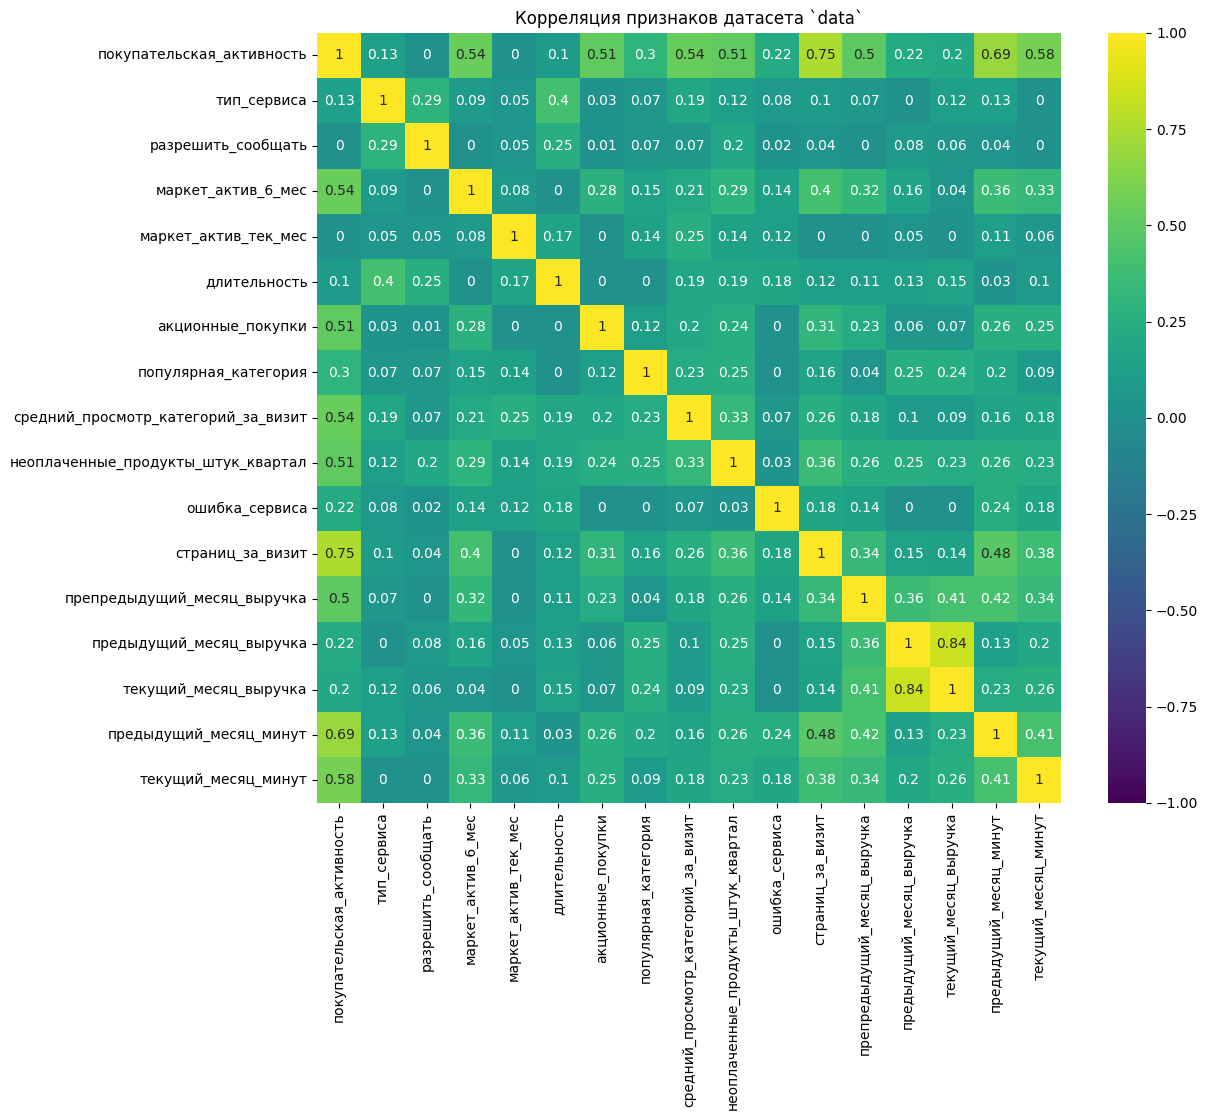

In [75]:
phi_corr = data.drop(['id'], 
     axis=1).phik_matrix(interval_cols=[
    'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
    'акционные_покупки', 'средний_просмотр_категорий_за_визит',
    'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 
    'страниц_за_визит', 'препредыдущий_месяц_выручка', 
    'предыдущий_месяц_выручка', 'текущий_месяц_выручка', 
    'предыдущий_месяц_минут', 'текущий_месяц_минут'
    ]).round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(phi_corr, annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title('Корреляция признаков датасета `data`')
plt.show()

### Промежуточный вывод

Судя по тепловым картам мультикоолинераности в наших данных нет.

## Использование пайплайнов

### Во время подготовки данных используем `'ColumnTransformer'`. Количественные и категориальные признаки обработаем в пайплайне раздельно. Для кодирования категориальных признаков используем как минимум два кодировщика, для масштабирования количественных — как минимум два скейлера.

In [76]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

X = data.drop(['покупательская_активность', 'id'], axis=1)
y = data['покупательская_активность']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = y)

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test =  le.transform(y_test)

ohe_columns = ['популярная_категория', 'разрешить_сообщать']
ord_columns = ['тип_сервиса']
num_columns = ['маркет_актив_6_мес', 'маркет_актив_тек_мес',
               'длительность', 'акционные_покупки', 'средний_просмотр_категорий_за_визит',
              'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит',
              'препредыдущий_месяц_выручка', 'предыдущий_месяц_выручка',
              'текущий_месяц_выручка', 'предыдущий_месяц_минут', 'текущий_месяц_минут']

ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False))
    ]
    )

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['стандарт', 'премиум'],
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('selector', SelectKBest()),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

### Обучим четыре модели: `KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и  SVC()`. Для каждой из них подберем как минимум один гиперпараметр. Выберем в качестве подходящей для задачи метрики - `ROC-AUC`. Используем эту метрику при подборе гиперпараметров.


Выбор метрики ROC AUC:
* дисбаланс классов в целевом признаке умеренный 61.7 / 38.3;
* ROC-AUC — это всеохватывающая метрика качества классификации. Она учитывает работу модели при всех возможных значениях порогов и поэтому не зависит от одного конкретного.

In [98]:
param_grid = [
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, 5),
        'selector__k': [5, 10, 15, 'all'],
        'selector__score_func': [f_classif],
        'preprocessor__num': [MinMaxScaler(), StandardScaler(), 'passthrough']  
    },
    
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 20),
        'selector__k': [8, 10, 12],
        'selector__score_func': [f_classif, mutual_info_classif],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'selector__k': [10, 15, 20],
        'selector__score_func': [f_classif],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
]

randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=3,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_iter=45
)
randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_)

y_test_pred = randomized_search.predict_proba(X_test)[:, 1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['популярная_категория',
                                                   'разрешить_сообщать']),
                                                 ('ord',
                                        

### Промежуточный вывод

1. Использовав один общий пайплайн для всех моделей и инструмент подбора гиперпараметров, мы нашли лучшую модель и гиперпараметры.
В нашем случае модель - **`'LogisticRegression'`** с гиперпараметрами: (C=4, penalty='l1'):
* С=4 - параметр регуляризации (обратная сила регуляризации), на достаточно низком уровне (умеренная регуляризация), что нам говорит о том что модель не сложная, не предрасположена к переобучению, а значит оптимально подходит к прогнозам на тестовых данных.
* penalty='l1' - L1-регуляризация обнуляет неважные признаки

2. Метрика лучшей модели на тренировочной выборке: 0.8959838036383492<br>
   Метрика ROC-AUC на тестовой выборке: 0.9236880115551276

## Анализ важности признаков

### Оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP

In [78]:
from sklearn.cluster import KMeans

  0%|          | 0/324 [00:00<?, ?it/s]

Best parameters: {'selector__score_func': <function f_classif at 0x000001E134E864C0>, 'selector__k': 8, 'preprocessor__num': MinMaxScaler(), 'models__n_neighbors': 17, 'models': KNeighborsClassifier(n_neighbors=17)}


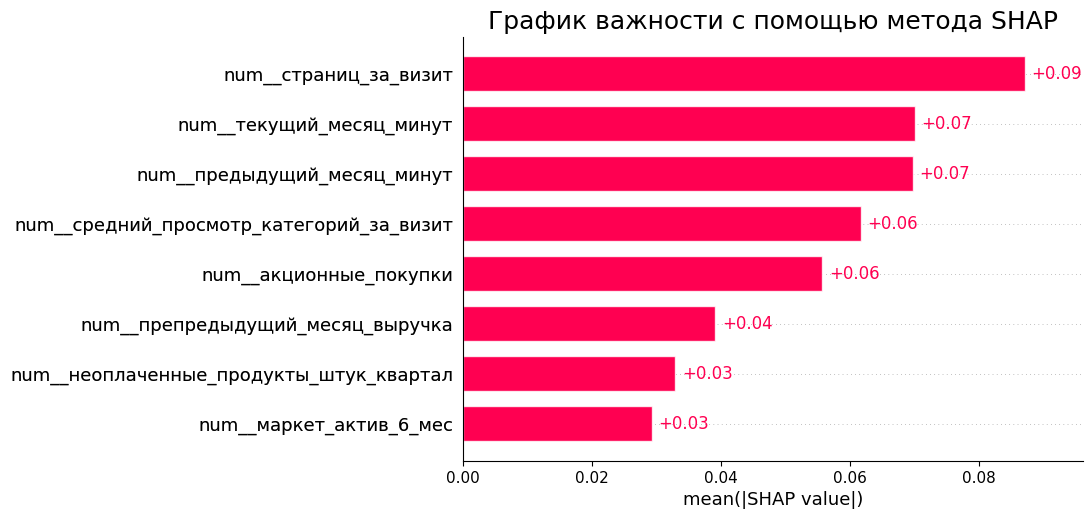

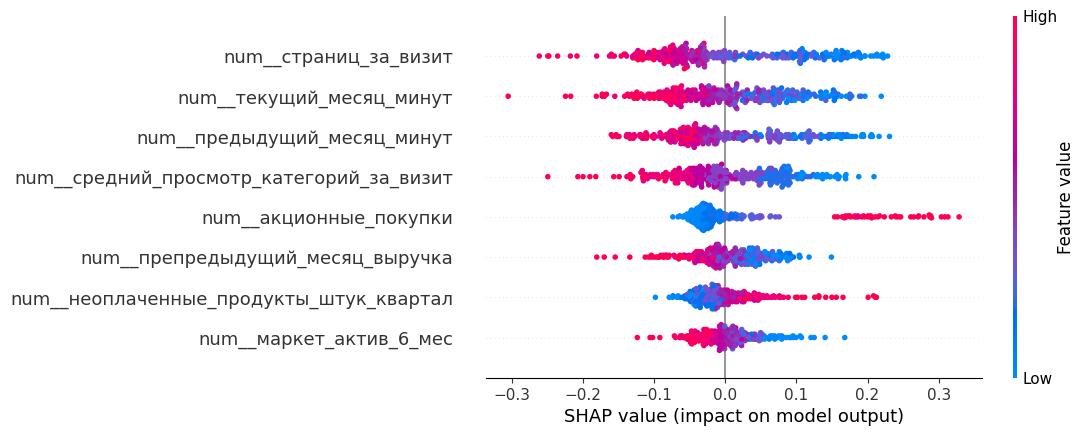

In [79]:
best_pipeline = randomized_search.best_estimator_
selector = best_pipeline.named_steps['selector']
knn_model = best_pipeline.named_steps['models']
    
preprocessor = best_pipeline.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

X_train_selected = selector.transform(X_train_transformed)
X_test_selected = selector.transform(X_test_transformed)
selected_mask = selector.get_support()
selected_feature_names = feature_names[selected_mask]

selector.feature_names_in_ = preprocessor.get_feature_names_out()
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names)

background = shap.sample(X_train_selected, 100)

explainer = shap.KernelExplainer(
        knn_model.predict_proba,
        background,
        feature_names=feature_names,
        n_jobs=-1
    )

shap_values = explainer(X_test_selected_df)

plt.title('График важности с помощью метода SHAP', size=18)
print(f'Best parameters: {randomized_search.best_params_}')
shap.plots.bar(shap_values[...,1])
shap.plots.beeswarm(shap_values[...,1], max_display=17) 
plt.show()

In [80]:
le.classes_
print(le.classes_)
print(le.transform(['Прежний уровень']), le.transform(['Снизилась']))

['Прежний уровень' 'Снизилась']
[0] [1]


### Промежуточный вывод

* Самые малозначимые признаки для лучше модели признаки с значимостью до 0.21 включительно:
    * ошибка сервиса;
    * предыдущий месяц выручка;
    * препредыдущий месяц выручка;
    * популярная категория_Косметика и аксесуары;
    * популярная категория_Товары для детей;
    * длительность;
    * тип сервиса
    * Техника для красоты и здоровья
    * мелкая бытовая техника и электроника

* Признаки, которые сильнее всего влияют на целевой признак, с значимостью выше 0.45:
    * страниц за визит;
    * акционные покупки;
    * средний просмотр категорий за визит

Стоит обратить внимание на аудиторию покупателей, у которых средний просмотр категорий за визит как и страниц за визит больше других. Также среди признаков в тройке лидеров находится такой признак как акционные покупки. Чуть меньше но все же ближе всех к тройке находится признак - количество минут за предыщий месяц. Данные признаки склоняют модель к прогнозу - активность покупателей на прежнем уровне.

Из 4х признаков лидеров, которые больше других влияют на общую оценку активности покупателей, образуются 2 группы:
   * признаки связанные с временем, проводимым покупателями на сайте;
   * проводимые акции на сайте магазина

## Сегментация покупателей

### Выполним сегментацию покупателей. Используем результаты моделирования и данные о прибыльности покупателей.

* объеденим наши данные в итоговой таблице **`'data'`** и данные о прибыльности покупателей **`'df_money_mean'`**;
* добавим к нашим обновленным данным колонку с прогнозированной вероятностью снижения активности покупателей, с помощью обученной модели

In [81]:
data_res = data.merge(df_money_mean, on='id', how='inner')

In [82]:
data_res.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,препредыдущий_месяц_выручка,предыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_минут,текущий_месяц_минут,прибыль
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10,4.16
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13,3.13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13,4.87
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11,4.21
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10,3.95


In [83]:
data_res['вероятность_снижения'] = best_pipeline.predict_proba(X)[:,1]
data_res.head()

C:\Users\admin\.conda\envs\practicum\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,препредыдущий_месяц_выручка,предыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_минут,текущий_месяц_минут,прибыль,вероятность_снижения
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10,4.16,0.882353
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13,3.13,0.411765
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13,4.87,0.705882
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11,4.21,1.000000
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10,3.95,0.647059


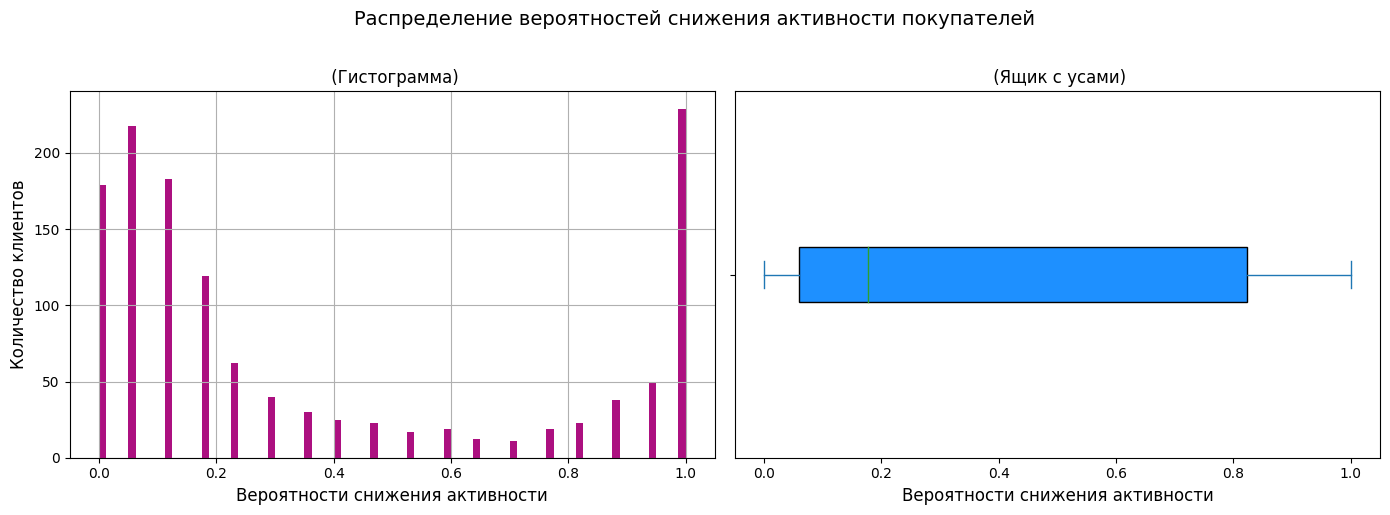

count    1296.000000
mean        0.379040
std         0.384347
min         0.000000
25%         0.058824
50%         0.176471
75%         0.823529
max         1.000000
dtype: float64


In [84]:
b = 'Распределение вероятностей снижения активности покупателей'
c = 'Вероятности снижения активности'
d = 'Количество клиентов'
e = 80
plotting_graphs_hist(data_res['вероятность_снижения'], b, c, d, e)

Судя по графику распределения вероятности снижения активности покупателей можно разделить на 3 сегмента:
* 0 - 0.45 - активные покупатели
* 0.45 - 0.7 - группа риска
* 0.7 - 1.0 - не активные покупатели<br>
Добавим колонку в результативный датафрейм с категориями покупателей

In [85]:
def categorize_income(row):
    income = row['вероятность_снижения']
    
    if 0 < income <= 0.4:
        return 'активные_покупатели'
    elif 0.4 < income <= 0.8:
        return 'группа_риска'
    else:
        return 'не_активные_покупатели'

data_res['категория'] = data_res.apply(categorize_income, axis=1)
data_res['категория'].unique()

array(['не_активные_покупатели', 'группа_риска', 'активные_покупатели'],
      dtype=object)

In [86]:
data_res['категория'].value_counts()

категория
активные_покупатели       652
не_активные_покупатели    518
группа_риска              126
Name: count, dtype: int64

Получается 719 - активные пользователи, 443 - не активные, 134 в зоне риска.

### Выберим группу покупателей и рассмотрим, как удержать её покупательскую активность
* из группы покупателей **`'активные пользователи'`** выделим сегмент с прибыльностью выше среднего;
* Проведем графическое и аналитическое исследование данной группы покупателей;
* Сделаем предложения по работе с сегментом для удержания и увеличения покупательской активности.

**Удержание обычно дешевле, чем привлечение новых (по данным `Harvard Business Review`, в 5–25 раз)**

In [87]:
def scatter_plotting_all(a, b, c, d, e):
    plt.figure(figsize=(14, 6))
    sns.scatterplot(data=data_res, x=a, y=b, hue='категория', style='категория', s=100)
    plt.title(c, fontsize=16)
    plt.xlabel(d, fontsize=14)
    plt.ylabel(e, fontsize=14)
    plt.legend(title='категория', loc='upper right', 
               bbox_to_anchor=(1.23, 1), title_fontsize=12, fontsize=10
              )
    plt.show()

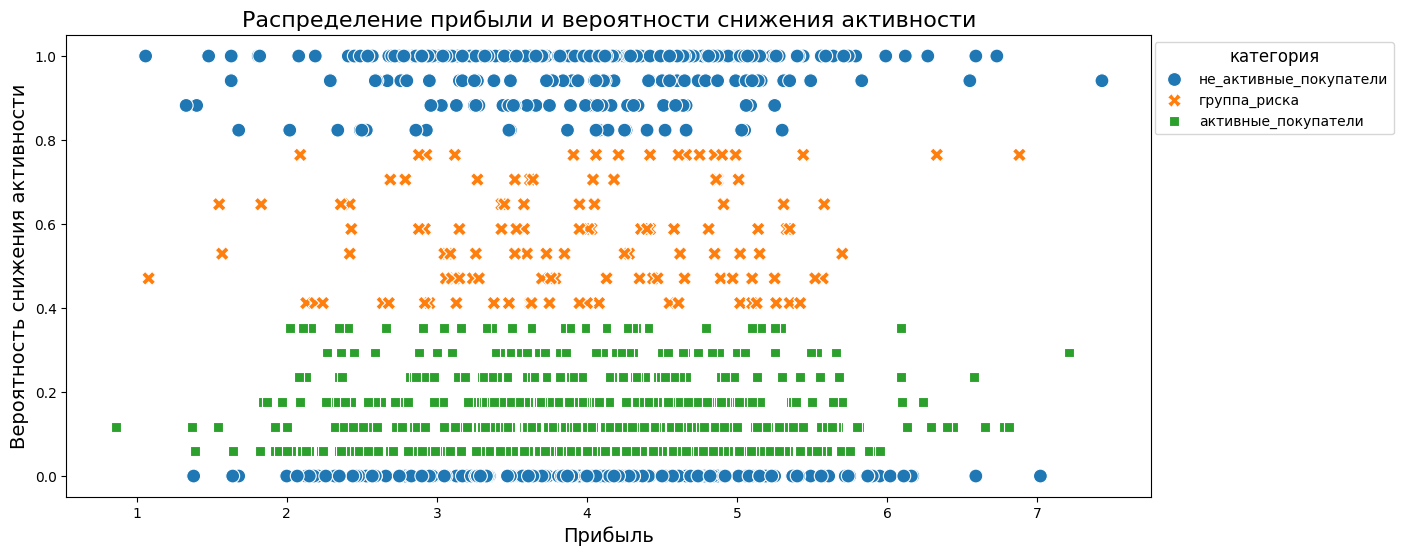

In [88]:
a = 'прибыль'
b = 'вероятность_снижения'
c = 'Распределение прибыли и вероятности снижения активности'
d = 'Прибыль'
e = 'Вероятность снижения активности'
scatter_plotting_all(a, b, c, d, e)

In [89]:
data_res[data_res['вероятность_снижения'] > 0.7]['прибыль'].describe()

count    369.000000
mean       4.005122
std        0.983199
min        1.060000
25%        3.330000
50%        4.060000
75%        4.650000
max        7.430000
Name: прибыль, dtype: float64

По визуализации распределения вероятности снижения активности и прибыли, с разделением на группы активности (а также по описательной статистике), видно что примерным центром прибыли является число 4. Примем это значение для определения нашего ключевого сегмента, с значением прибыли выше 4, и значением вероятности снижения активности выше 0.7<br>
Так как эта часть сегмента приносит большую часть прибыли, это является приоритетом для удержания данного сегмента.

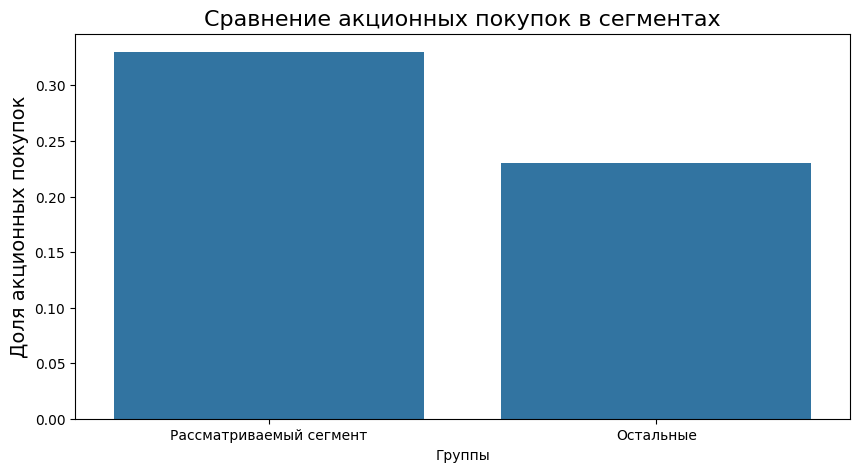

In [90]:
high_risk = data_res[(data_res['вероятность_снижения'] > 0.7) & (data_res['прибыль'] > 4.0)]
other_clients = data_res[~data_res.index.isin(high_risk.index)]

discount_stats = pd.DataFrame({
    'Группы': ['Рассматриваемый сегмент', 'Остальные'],
    'Средние акционные покупки': [
        high_risk['акционные_покупки'].median(),
        other_clients['акционные_покупки'].median()
    ]
})

plt.figure(figsize=(10, 5))
sns.barplot(data=discount_stats, x='Группы', y='Средние акционные покупки')
plt.title('Сравнение акционных покупок в сегментах', size=16)
plt.ylabel('Доля акционных покупок', size=14)
plt.show()

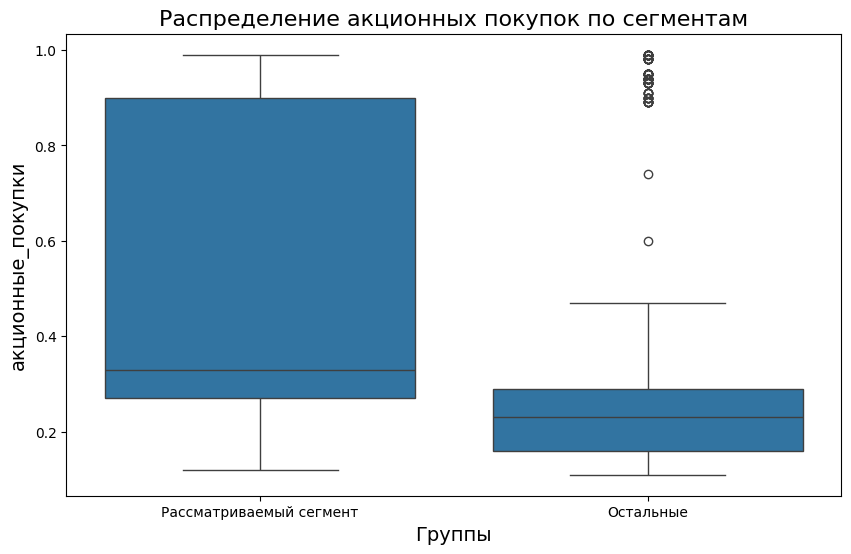

In [91]:
data_res['Сегмент'] = 'Остальные'
data_res.loc[high_risk.index, 'Сегмент'] = 'Рассматриваемый сегмент'

plt.figure(figsize=(10, 6))
sns.boxplot(data=data_res, x='Сегмент', y='акционные_покупки')
plt.title('Распределение акционных покупок по сегментам', size=16)
plt.xlabel('Группы', size=14)
plt.ylabel('акционные_покупки', size=14)
plt.show()

По данным графикам видно, что у выбранного сегмента высокая вовлеченность в акционные покупки. Так как этот сегмент наиболее отзывчив к акциям, но при этом рискует уйти при отсутствии выгодных предложений:
* можно внедрить персональные скидки на часто покупаемые товары;
* Использовать данные о прошлых покупках для предложений со скидкой;
* Провести опрос среди этого сегмента, чтобы узнать, какие типы акций их мотивируют больше всего

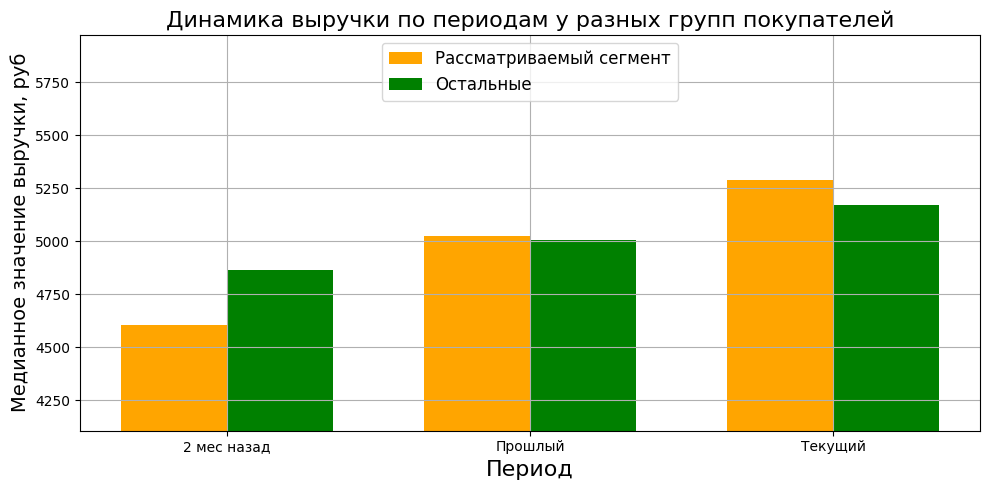

In [92]:
periods = ['препредыдущий_месяц_выручка', 'предыдущий_месяц_выручка', 'текущий_месяц_выручка']
x = range(len(periods))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar([i - width/2 for i in x], high_risk[periods].median(), width, label='Рассматриваемый сегмент', color='orange')
plt.bar([i + width/2 for i in x], other_clients[periods].median(), width, label='Остальные', color='green')

max_value = high_risk['текущий_месяц_выручка'].sort_index().max()
plt.ylim(max_value * 0.55, max_value * 0.8)
plt.xticks(x, ['2 мес назад', 'Прошлый', 'Текущий'])
plt.legend(loc='upper center', fontsize=12)
plt.grid(True)
plt.title('Динамика выручки по периодам у разных групп покупателей', size=16)
plt.xlabel('Период', size=16)
plt.ylabel('Медианное значение выручки, руб', size=14)
plt.tight_layout()
plt.show()

На данном графике явно видно, что у выбранного сегмента стабильная динамика роста выручки каждый месяц, и если сравнивать с остальными, линия тренда визуально имеет больший угол наклона к горизонтали (динамика роста выручки выше), это говорит о том что если у выбранного сегмента будет снижаться активность - возможно может привести к значительному снижению выручки

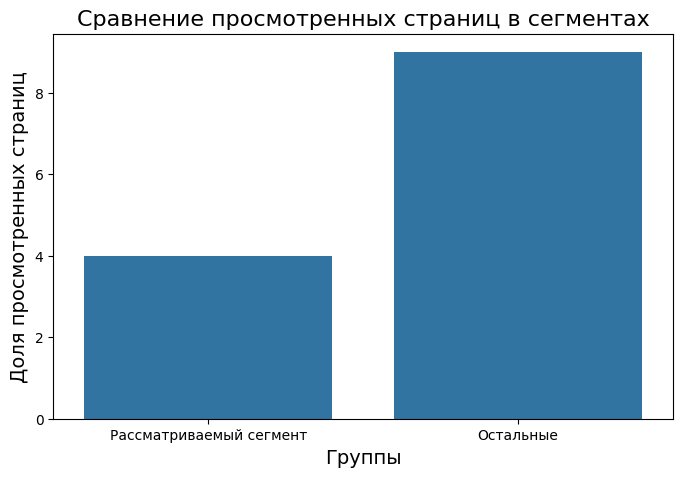

In [93]:
discount_stats = pd.DataFrame({
    'Группы': ['Рассматриваемый сегмент', 'Остальные'],
    'страниц_за_визит': [
        high_risk['страниц_за_визит'].median(),
        other_clients['страниц_за_визит'].median()
    ]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=discount_stats, x='Группы', y='страниц_за_визит')
plt.title('Сравнение просмотренных страниц в сегментах', size=16)
plt.ylabel('Доля просмотренных страниц', size=14)
plt.xlabel('Группы', size=14)
plt.show()

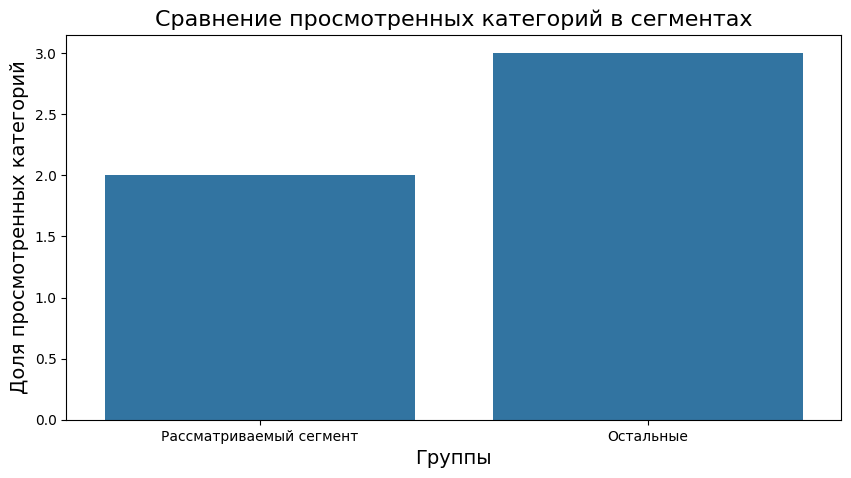

In [94]:
discount_stats = pd.DataFrame({
    'Группы': ['Рассматриваемый сегмент', 'Остальные'],
    'средний_просмотр_категорий_за_визит': [
        high_risk['средний_просмотр_категорий_за_визит'].median(),
        other_clients['средний_просмотр_категорий_за_визит'].median()
    ]
})

plt.figure(figsize=(10, 5))
sns.barplot(data=discount_stats, x='Группы', y='средний_просмотр_категорий_за_визит')
plt.title('Сравнение просмотренных категорий в сегментах', size=16)
plt.ylabel('Доля просмотренных категорий', size=14)
plt.xlabel('Группы', size=14)
plt.show()

**`'Рассматриваемый сегмент'`** показывает меньший охват категорий, **`'Остальные'`** демонстрируют более высокую долю просмотренных категорий.<br>
Для **`'остальных'`**:
* Широкий просмотр категорий указывает на исследовательское поведение;
* Возможны 2 сценария: активный поиск оптимального варианта или отсутствие четких предпочтений
Для **`'рассматриваемого сегмента'`**:
* Узкий фокус на определенных категориях может означать:
    * Сформировавшиеся предпочтения;
    * Недостаточное вовлечение в другие категории;
    * Возможную лояльность к конкретным типам товаров
    
Для **`'рассматриваемого сегмента'`** (узкий просмотр) можно пореккомендовать:
* Разработать стратегию расширения покупательского кругозора:
    * Таргетированные промо-кампании;
    * Спецпредложения с кэшбэком за первую покупку в новой категории
    * Оптимизировать навигацию между категориями

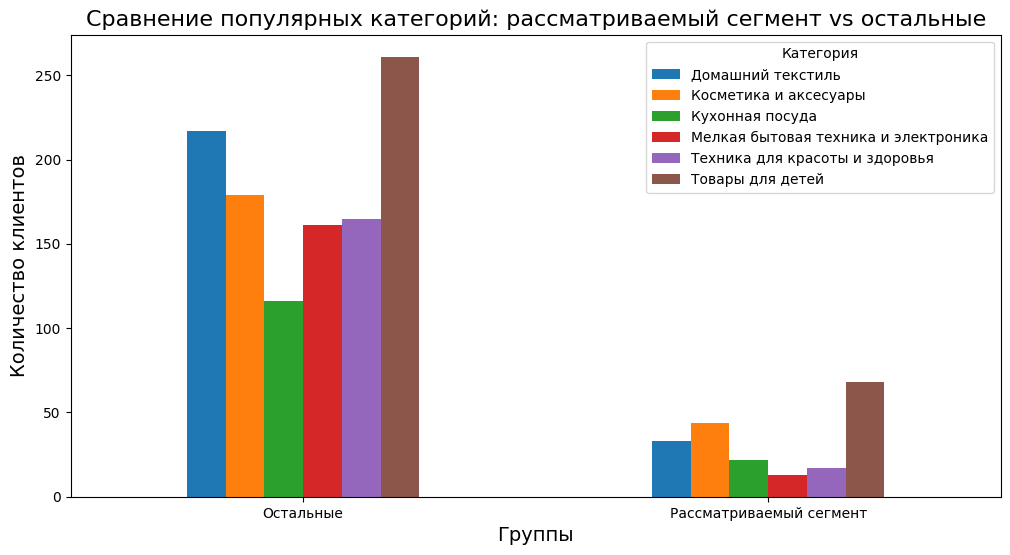

In [95]:
grouped = data_res.groupby(['Сегмент', 'популярная_категория']).size().unstack()

grouped.plot(kind='bar', figsize=(12, 6))
plt.title('Сравнение популярных категорий: рассматриваемый сегмент vs остальные', size=16)
plt.ylabel('Количество клиентов', size=14)
plt.xlabel('Группы', size=14)
plt.xticks(rotation=0)
plt.legend(title='Категория')
plt.show()

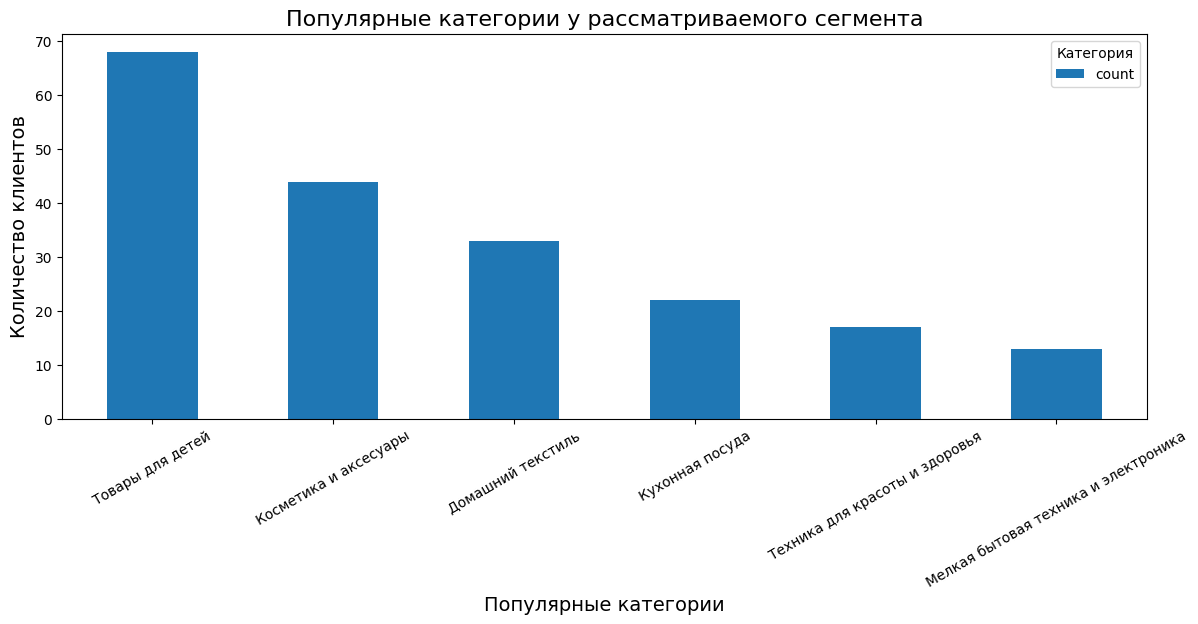

In [96]:
plt.figure(figsize=(14, 5))
high_risk['популярная_категория'].value_counts().plot(kind='bar')
plt.title('Популярные категории у рассматриваемого сегмента', size=16)
plt.ylabel('Количество клиентов', size=14)
plt.xlabel('Популярные категории', size=14)
plt.xticks(rotation=30)
plt.legend(title='Категория')
plt.show()

**`'Рассматриваемый сегмент'`** активнее покупает товары для детей, косметику и аксесуары и домашний текстиль:
* Это может указывать на семейную аудиторию или потребителей с акцентом на домашний уют.
У **`'Остальные'`** в лидерах категории товары для детей, домашний текстиль и на 3м месте косметика и аксесуары, но вплотную приближены такие категории как: мелкая бытовая техника и электронника, техника для красоты и здоровья.
* Можно предположить косвенно что в **`'Рассматриваемом сегменте'`** преобладает более женская аудитория судя по популярным категориям в сегментах, для однозначного утверждения мало данных. 

Рекомендации для **`'Рассматриваемого сегмента'`**
* Персонализация ассортимента:
    * Увеличить долю домашнего текстиля и товаров для детей в рекомендациях;
    * Создать тематические подборки (например, «Все для уюта в доме»)

### Промежуточный вывод

Была выполнена сегментация покупателей, используя результаты моделирования и данные о прибыльности покупателей.

* объеденили наши данные в итоговой таблице **`'data'`** и данные о прибыльности покупателей **`'df_money_mean'`**;
* добавили к нашим обновленным данным колонку с прогнозированной вероятностью снижения активности покупателей, с помощью обученной модели
* Был построен график распределение вероятностей снижения активности покупателей и 'ящик с усами':
    * Судя по графику распределения вероятности снижения активности покупателей можно разделить на 3 сегмента:
        * 0 - 0.45 - активные покупатели
        * 0.45 - 0.7 - группа риска
        * 0.7 - 1.0 - не активные покупатели<br>
    * Добавим колонку в результативный датафрейм с категориями покупателей
        * В результате разделения по категориям получилось: 815 - активные пользователи, 366 - не активные, 115 в зоне риска.
* Была выбрана группа покупателей и рассмотренно, как удержать её покупательскую активность (**Удержание обычно дешевле, чем привлечение новых (по данным `Harvard Business Review`, в 5–25 раз)**):
    * из группы покупателей **`'активные пользователи'`** выделили сегмент с прибыльностью выше среднего;
        * По визуализации распределения вероятности снижения активности и прибыли, с разделением на группы активности (а также по описательной статистике), видно что примерным центром прибыли является число 4. Примем это значение для определения нашего ключевого сегмента, с значением прибыли выше 4, и значением вероятности снижения активности выше 0.7. Так как эта часть сегмента приносит большую часть прибыли, это является приоритетом для удержания данного сегмента.
    * Провели графическое и аналитическое исследование данной группы покупателей;
        * **Акционные покупки**. По графикам видно, что у выбранного сегмента высокая вовлеченность в акционные покупки. Так как этот сегмент наиболее отзывчив к акциям, но при этом рискует уйти при отсутствии выгодных предложений:
            * можно внедрить персональные скидки на часто покупаемые товары;
            * Использовать данные о прошлых покупках для предложений со скидкой;
            * Провести опрос среди этого сегмента, чтобы узнать, какие типы акций их мотивируют больше всего
        * **Динамика выручки по периодам у разных групп покупателей**. По графикам явно видно, что у выбранного сегмента стабильная динамика роста выручки каждый месяц, и если сравнивать с остальными, линия тренда визуально имеет бОльший угол наклона к горизонтали (динамика роста выручки выше), это говорит о том что если у выбранного сегмента будет снижаться активность - возможно может привести к значительному снижению выручки (сегмент выбран приоритетный)
        * **Средний просмотр категорий за визит**, просмотренные страницы. **`'Рассматриваемый сегмент'`** показывает меньший охват категорий, **`'Остальные'`** демонстрируют более высокую долю просмотренных категорий.<br>
            * Для **`'остальных'`**:
                * Широкий просмотр категорий указывает на исследовательское поведение;
                * Возможны 2 сценария: активный поиск оптимального варианта или отсутствие четких предпочтений
            * Для **`'рассматриваемого сегмента'`**:
                * Узкий фокус на определенных категориях может означать:
                    * Сформировавшиеся предпочтения;
                    * Недостаточное вовлечение в другие категории;
                    * Возможную лояльность к конкретным типам товаров
    
            * Для **`'рассматриваемого сегмента'`** (узкий просмотр) можно пореккомендовать:
                * Разработать стратегию расширения покупательского кругозора:
                * Таргетированные промо-кампании;
                * Спецпредложения с кэшбэком за первую покупку в новой категории
                * Оптимизировать навигацию между категориями
 
        * **Популярные категории**. **`'Рассматриваемый сегмент'`** активнее покупает товары для детей, косметику и аксесуары и домашний текстиль:
            * Это может указывать на семейную аудиторию или потребителей с акцентом на домашний уют.
                * У **`'Остальные'`** в лидерах категории товары для детей, домашний текстиль и на 3м месте косметика и аксесуары, но вплотную приближены такие категории как: мелкая бытовая техника и электронника, техника для красоты и здоровья.
                * Можно предположить косвенно что в **`'Рассматриваемом сегменте'`** преобладает более женская аудитория судя по популярным категориям в сегментах, для однозначного утверждения мало данных. 

        * Рекомендации для **`'Рассматриваемого сегмента'`**
            * Персонализация ассортимента:
                * Увеличить долю домашнего текстиля и товаров для детей в рекомендациях;
                * Создать тематические подборки (например, «Все для уюта в доме»)

## Общий вывод

### Описание задачи

**«В один клик»** — современная компания, поэтому её руководство не хочет принимать решения просто так — только на основе анализа данных и бизнес-моделирования. У компании есть небольшой отдел цифровых технологий, и вам предстоит побыть в роли стажёра в этом отделе.<br> 

Итак, вашему отделу поручили разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.<br>

1. Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.
2. В исследование нужно включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца.
3. Используя данные модели и данные о прибыльности клиентов, нужно выделить сегменты покупателей и разработать для них персонализированные предложения.<br>

### Описание исходных данных и проведённой предобработки

#### Описание исходных данных
1. Файл **`'market_file.csv'`** таблица, которая содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.

* **`'id'`** — номер покупателя в корпоративной базе данных.
* **`'Покупательская активность'`** — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
* **`'Тип сервиса'`** — уровень сервиса, например «премиум» и «стандарт».
* **`'Разрешить сообщать'`** — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
* **`'Маркет_актив_6_мес'`** — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
* **`'Маркет_актив_тек_мес'`** — количество маркетинговых коммуникаций в текущем месяце.
* **`'Длительность'`** — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
* **`'Акционные_покупки'`** — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
* **`'Популярная_категория'`** — самая популярная категория товаров у покупателя за последние 6 месяцев.
* **`'Средний_просмотр_категорий_за_визит'`** — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
* **`'Неоплаченные_продукты_штук_квартал'`** — общее число неоплаченных товаров в корзине за последние 3 месяца.
* **`'Ошибка_сервиса'`** — число сбоев, которые коснулись покупателя во время посещения сайта.
* **`'Страниц_за_визит'`** — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.

2. Файл **`'market_money.csv'`** таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.

* **`'id'`** — номер покупателя в корпоративной базе данных.
* **`'Период'`** — название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц'.
* **`'Выручка'`** — сумма выручки за период.

3. Файл **`'market_time.csv'`** таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.

* **`'id'`** — номер покупателя в корпоративной базе данных.
* **`'Период'`** — название периода, во время которого зафиксировано общее время.
* **`'минут'`** — значение времени, проведённого на сайте, в минутах.

4. Файл **`'money.csv'`** Таблица с данными о среднемесячной прибыли продавца за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.

* **`'id'`** — номер покупателя в корпоративной базе данных.
* **`'Прибыль'`** — значение прибыли.

#### Проведённая предобработка

На данном этапе мы проверили:
* проверили на наличие дубликатов:
    * явные дубликаты не обнаружены;
    * обнаружили неявные дубликаты в датасете **`'df_market_file'`**, привели данные к одному виду
* привели в соответствие данным их тип в датасете **`'df_money_mean`'**;
* приоверили на содержание артефактов числовые значения во всех датафреймах - отстутствуют.

### Поиск лучшей модели

* Во время подготовки данных использовалcя **`'ColumnTransformer'`**. Количественные и категориальные признаки обработаны в пайплайне раздельно. Для кодирования категориальных признаков использовались кодировщики **`'OneHotEncoder, OrdinalEncoder, LabelEncoder'`**, для масштабирования количественных — скейлеры **`'MinMaxScaler, StandardScaler'`**;
* для каждой модели подготовили данные с разным кодированием и масштабированием;
* обучили четыре модели: **`'KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и  SVC()'`**. Для каждой из них подобрали гиперпараметры;
* Выбор метрики ROC AUC:
    * дисбаланс классов в целевом признаке умеренный 61.7 / 38.3;
    * ROC-AUC — это всеохватывающая метрика качества классификации. Она учитывает работу модели при всех возможных значениях порогов и поэтому не зависит от одного конкретного.
* Использовав один общий пайплайн для всех моделей и инструмент подбора гиперпараметров, мы нашли лучшую модель и гиперпараметры.
    * В нашем случае модель - **`'LogisticRegression'`** с гиперпараметрами: (C=4, penalty='l1'):
        * С=4 - параметр регуляризации (обратная сила регуляризации), на достаточно низком уровне (умеренная регуляризация), что нам говорит о том что модель не сложная, не предрасположена к переобучению, а значит оптимально подходит к прогнозам на тестовых данных.
        * penalty='l1' - L1-регуляризация обнуляет неважные признаки

        * Метрика лучшей модели на тренировочной выборке: 0.8959838036383492<br>
          Метрика ROC-AUC на тестовой выборке: 0.9236880115551276
          
### Анализ важности признаков
* оценили важность признаков для лучшей модели и построим график важности с помощью метода SHAP
    * Самые малозначимые признаки для лучше модели признаки с значимостью до 0.21 включительно:
        * ошибка сервиса;
        * предыдущий месяц выручка;
        * препредыдущий месяц выручка;
        * популярная категория_Косметика и аксесуары;
        * популярная категория_Товары для детей;
        * длительность;
        * тип сервиса
        * Техника для красоты и здоровья
        * мелкая бытовая техника и электроника

    * Признаки, которые сильнее всего влияют на целевой признак, с значимостью выше 0.45:
        * страниц за визит;
        * акционные покупки;
        * средний просмотр категорий за визит

* Стоит обратить внимание на аудиторию покупателей, у которых средний просмотр категорий за визит как и страниц за визит больше других. Также среди признаков в тройке лидеров находится такой признак как акционные покупки. Чуть меньше но все же ближе всех к тройке находится признак - количество минут за предыщий месяц. Данные признаки склоняют модель к прогнозу - активность покупателей на прежнем уровне.

* Из 4х признаков лидеров, которые больше других влияют на общую оценку активности покупателей, образуются 2 группы:
   * признаки связанные с временем, проводимым покупателями на сайте;
   * проводимые акции на сайте магазина

### Сегментация покупателей

Была выполнена сегментация покупателей, используя результаты моделирования и данные о прибыльности покупателей.

* объеденили наши данные в итоговой таблице **`'data'`** и данные о прибыльности покупателей **`'df_money_mean'`**;
* добавили к нашим обновленным данным колонку с прогнозированной вероятностью снижения активности покупателей, с помощью обученной модели
* Был построен график распределение вероятностей снижения активности покупателей и 'ящик с усами':
    * Судя по графику распределения вероятности снижения активности покупателей можно разделить на 3 сегмента:
        * 0 - 0.45 - активные покупатели
        * 0.45 - 0.7 - группа риска
        * 0.7 - 1.0 - не активные покупатели<br>
    * Добавим колонку в результативный датафрейм с категориями покупателей
        * В результате разделения по категориям получилось: 815 - активные пользователи, 366 - не активные, 115 в зоне риска.
* Была выбрана группа покупателей и рассмотренно, как удержать её покупательскую активность (**Удержание обычно дешевле, чем привлечение новых (по данным `Harvard Business Review`, в 5–25 раз)**):
    * из группы покупателей **`'активные пользователи'`** выделили сегмент с прибыльностью выше среднего;
        * По визуализации распределения вероятности снижения активности и прибыли, с разделением на группы активности (а также по описательной статистике), видно что примерным центром прибыли является число 4. Примем это значение для определения нашего ключевого сегмента, с значением прибыли выше 4, и значением вероятности снижения активности выше 0.7. Так как эта часть сегмента приносит большую часть прибыли, это является приоритетом для удержания данного сегмента.
    * Провели графическое и аналитическое исследование данной группы покупателей;
        * **Акционные покупки**. По графикам видно, что у выбранного сегмента высокая вовлеченность в акционные покупки. Так как этот сегмент наиболее отзывчив к акциям, но при этом рискует уйти при отсутствии выгодных предложений:
            * можно внедрить персональные скидки на часто покупаемые товары;
            * Использовать данные о прошлых покупках для предложений со скидкой;
            * Провести опрос среди этого сегмента, чтобы узнать, какие типы акций их мотивируют больше всего
        * **Динамика выручки по периодам у разных групп покупателей**. По графикам явно видно, что у выбранного сегмента стабильная динамика роста выручки каждый месяц, и если сравнивать с остальными, линия тренда визуально имеет бОльший угол наклона к горизонтали (динамика роста выручки выше), это говорит о том что если у выбранного сегмента будет снижаться активность - возможно может привести к значительному снижению выручки (сегмент выбран приоритетный)
        * **Средний просмотр категорий за визит**, просмотренные страницы. **`'Рассматриваемый сегмент'`** показывает меньший охват категорий, **`'Остальные'`** демонстрируют более высокую долю просмотренных категорий.<br>
            * Для **`'остальных'`**:
                * Широкий просмотр категорий указывает на исследовательское поведение;
                * Возможны 2 сценария: активный поиск оптимального варианта или отсутствие четких предпочтений
            * Для **`'рассматриваемого сегмента'`**:
                * Узкий фокус на определенных категориях может означать:
                    * Сформировавшиеся предпочтения;
                    * Недостаточное вовлечение в другие категории;
                    * Возможную лояльность к конкретным типам товаров
    
            * Для **`'рассматриваемого сегмента'`** (узкий просмотр) можно пореккомендовать:
                * Разработать стратегию расширения покупательского кругозора:
                * Таргетированные промо-кампании;
                * Спецпредложения с кэшбэком за первую покупку в новой категории
                * Оптимизировать навигацию между категориями
 
        * **Популярные категории**. **`'Рассматриваемый сегмент'`** активнее покупает товары для детей, косметику и аксесуары и домашний текстиль:
            * Это может указывать на семейную аудиторию или потребителей с акцентом на домашний уют.
                * У **`'Остальные'`** в лидерах категории товары для детей, домашний текстиль и на 3м месте косметика и аксесуары, но вплотную приближены такие категории как: мелкая бытовая техника и электронника, техника для красоты и здоровья.
                * Можно предположить косвенно что в **`'Рассматриваемом сегменте'`** преобладает более женская аудитория судя по популярным категориям в сегментах, для однозначного утверждения мало данных. 

        * Рекомендации для **`'Рассматриваемого сегмента'`**
            * Персонализация ассортимента:
                * Увеличить долю домашнего текстиля и товаров для детей в рекомендациях;
                * Создать тематические подборки (например, «Все для уюта в доме»)